In [1]:
import numpy as np
import glob
import matplotlib.pyplot as plt
from legendmeta import LegendMetadata
from dbetto import Props, TextDB, AttrsDict
from tqdm.notebook import tqdm
import polars as pl
import awkward as ak

from bosonic_dm.efficiency import compute_efficiency_from_lazyframe, filter_non_zero_efficiency
from bosonic_dm.io import get_values_sorted, get_mean_fcc_det_type, build_parquet_dataset
from bosonic_dm.plotting.spectra import plot_lar_cut_spectra

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
version = "v2.1.5"
base = f"/global/cfs/projectdirs/m2676/data/lngs/l200/public/prodenv/prod-blind/ref/{version}/"
scratch_folder = "/pscratch/sd/b/borrfran/sim-v1.1.0-20260401/"
# metadata2_path = os.environ["METADATA"]
metadata2_path = "/global/homes/b/borrfran/workspace/l200/legend-metadata"
config = Props.read_from(base+"/config.json", subst_pathvar=True)['setups']['l200']['paths']


meta = LegendMetadata(config['metadata'])
meta2 = LegendMetadata(metadata2_path)

timestamp = meta.dataprod.runinfo.p03.r000.phy.start_key

chmap = meta.channelmap(timestamp)
chmap_ak = ak.Array(chmap.group("system").geds.values())
ges_sorted = chmap_ak.name

DET_TYPES = ("BEGe", "COAX", "ICPC", "PPC")
DET_TYPE_MAP = {"B": "BEGe", "C": "COAX", "V": "ICPC", "P": "PPC"}
DET_TYPE_COLOR = {
    "BEGe": "tab:blue",
    "COAX": "tab:orange",
    "ICPC": "tab:green",
    "PPC": "tab:red",
}

simulated_energies = list(range(200, 1100, 100))

datasets_outdir = "../data//v1/parquet/"
dictionaries_dir = "../data/v1/dictionaries"

rawid_by_det_type = Props.read_from(f'{dictionaries_dir}/rawid_by_det_type.yaml')
eres_dict = Props.read_from(f"{dictionaries_dir}/eres_per_det_tot.yaml")

interaction = "dark-compton"
pq_version = "3"

could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldataprod/config/evt/p14_r0%%_evt_phy_overwrite.yaml, reason: ParserError('while parsing a block mapping', <yaml._yaml.Mark object at 0x7f9b42367790>, 'did not find expected key', <yaml._yaml.Mark object at 0x7f9b42367470>)
could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldataprod/config/evt/p14_r0%%_evt_phy_overwrite.yaml, reason: ParserError('while parsing a block mapping', <yaml._yaml.Mark object at 0x7f9b42190770>, 'did not find expected key', <yaml._yaml.Mark object at 0x7f9b42190540>)
could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldataprod/config/evt/p14_r0%%_evt_phy_overwrite.yaml, reason: ParserError('while parsing a block mapping', <yaml._yaml.Mark object at 0x7f9b421b3f60>, 'did not find expected key', <yaml._yaml.Mark object at 0x7f9b421b3f10>)
could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldat

# Popolate Parquet dataset from simulation

In [59]:
outdir_name = "dark-compton2"
job_base="fromfile_dark_compton_{tag}_hpge_bulk"

build_parquet_dataset(
    simulated_energies,
    scratch_folder=scratch_folder,
    job_base=job_base,
    outdir_name= outdir_name,
    overwrite=True,
)

  0%|          | 0/9 [00:00<?, ?it/s]

# Read Parquet dataset

In [3]:
outdir_name = f"{interaction}{pq_version}"

lf = pl.scan_parquet(
    f"{datasets_outdir}/{outdir_name}",
    hive_partitioning=True
)

## Plot energy spectrum by detector type

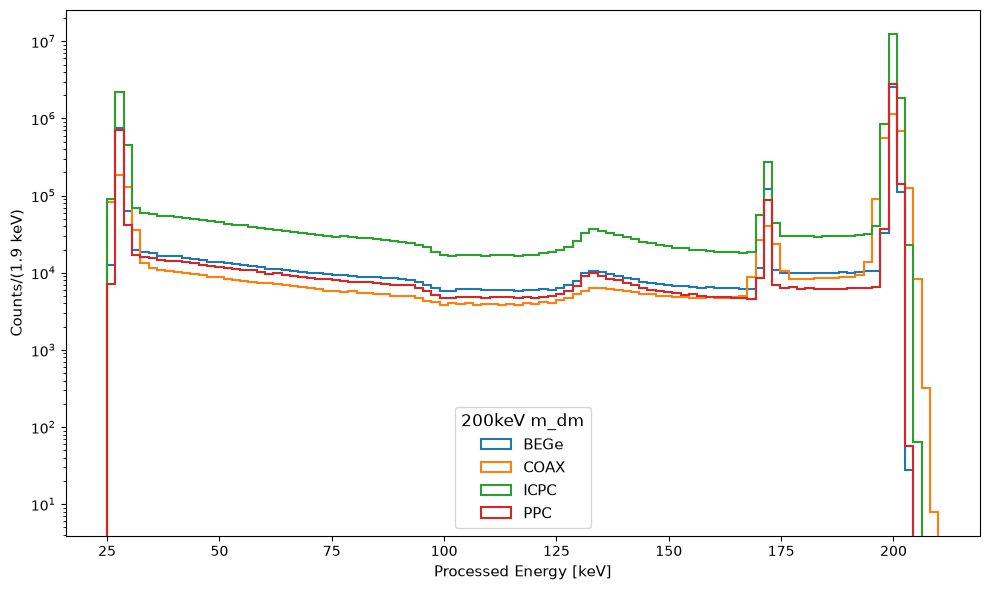

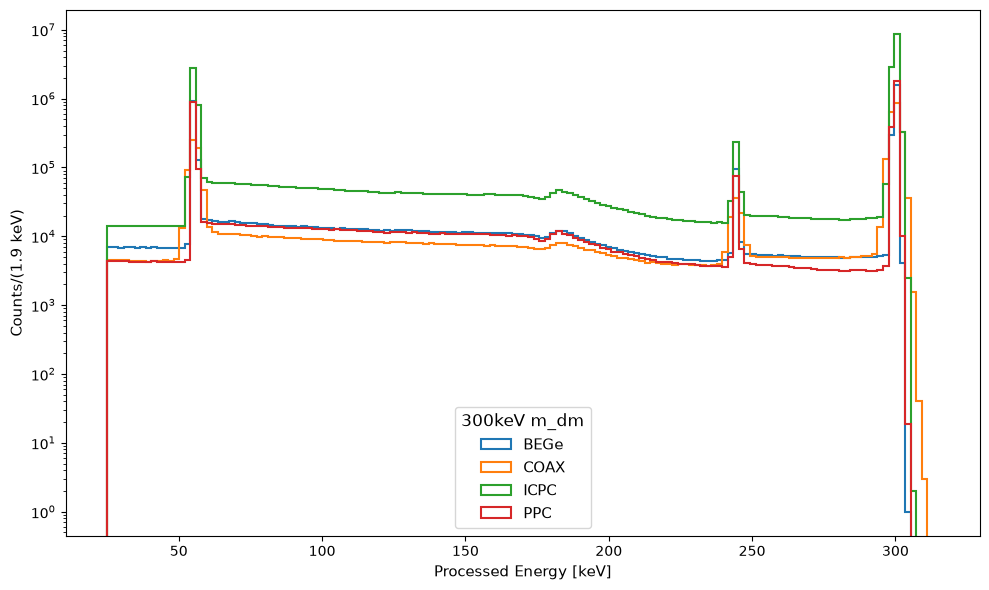

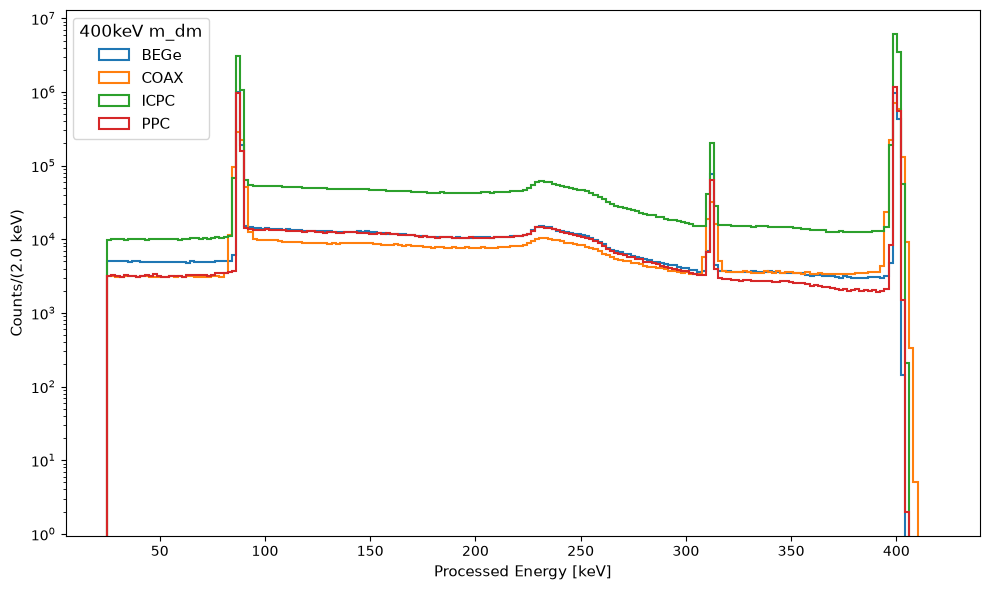

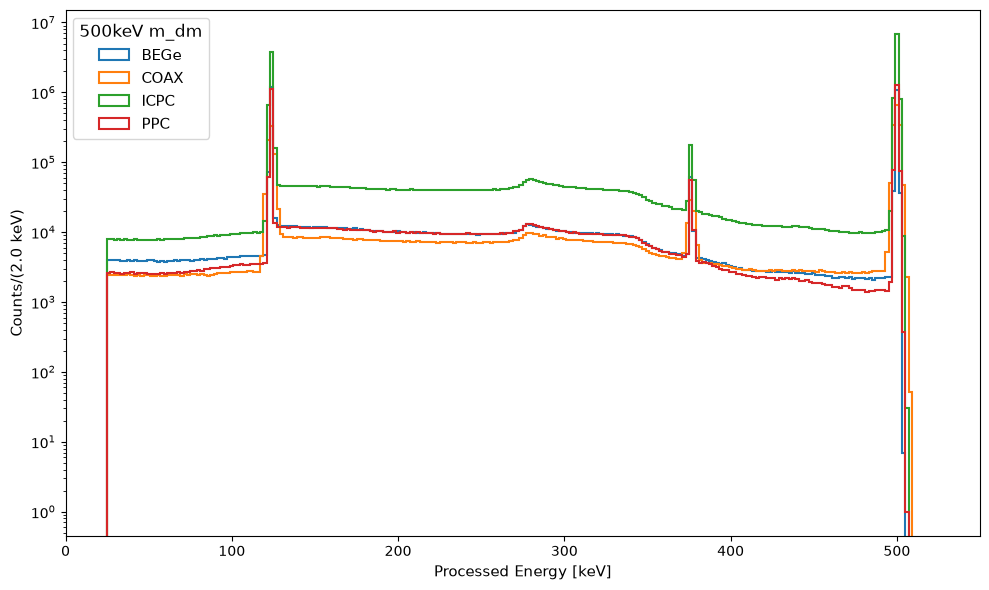

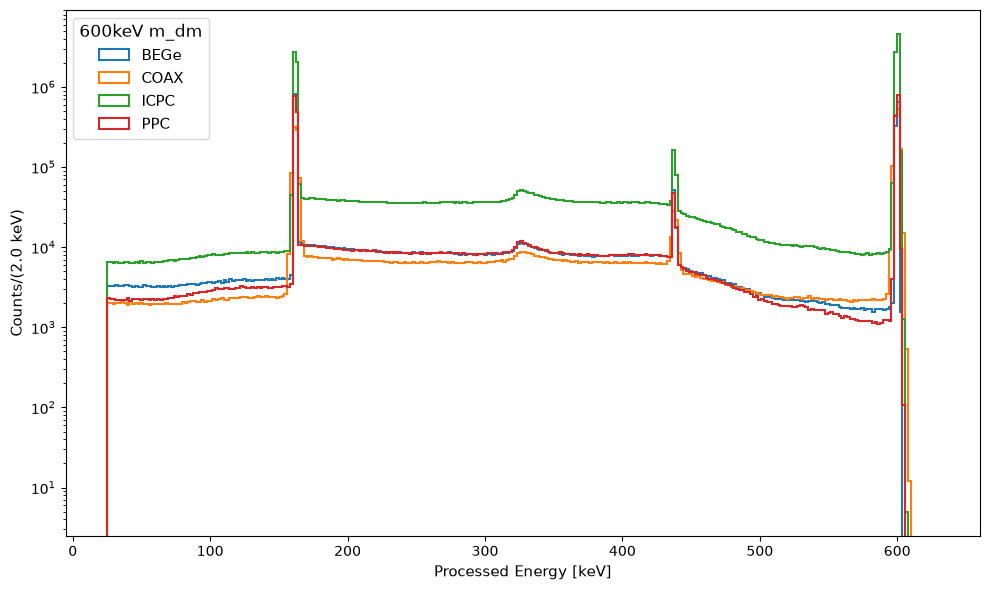

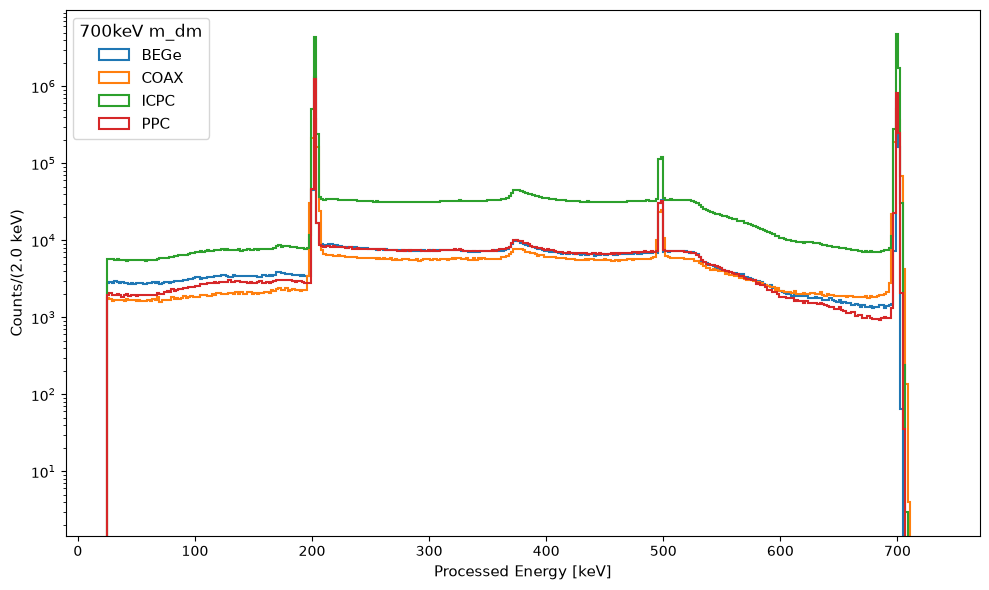

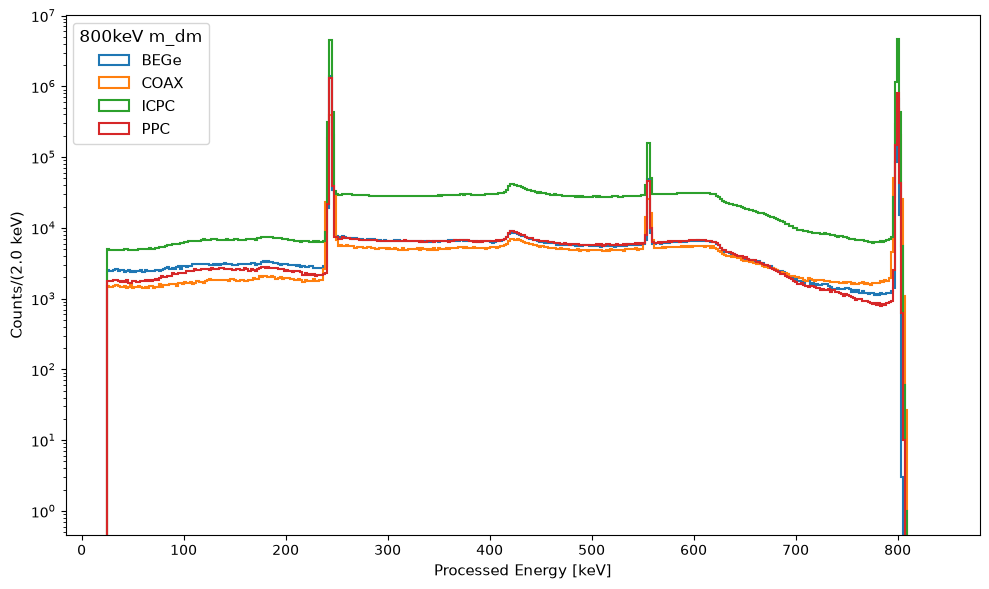

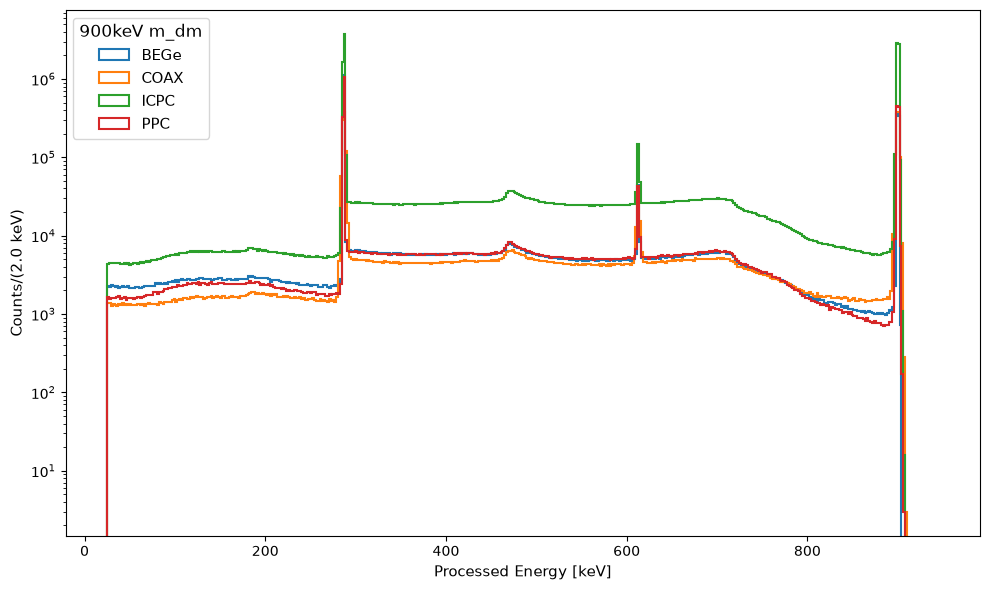

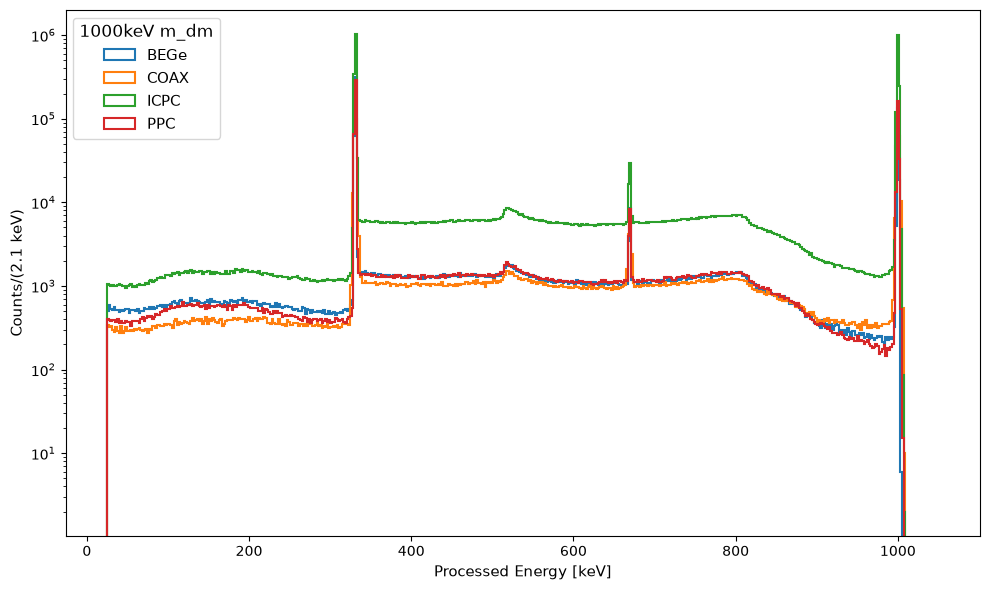

In [13]:
lw = 1.5
save_fig = False
for ene in simulated_energies:
    
    plt.figure(figsize=(10, 6))
    
    bins = int(ene/2)

    _, bin_edges = np.histogram([], bins=bins, range=(25, ene*1.05))
    bin_width = bin_edges[1] - bin_edges[0]

    for det_type in DET_TYPES:
        filtered_df = (
            lf.filter(
                (pl.col("sim_e") == ene) &
                pl.col("rawid").is_in(rawid_by_det_type[det_type])
            )
            .select([
                "energy"
            ])
            .collect()
        )
        
        plt.hist(
            filtered_df['energy'], 
            bins=bin_edges, 
            label=det_type, 
            histtype="step", 
            linewidth=lw
        )
    
    plt.yscale("log")
    plt.legend(title=f"{ene}keV m_dm", title_fontsize=12, fontsize=11)
    plt.xlabel("Processed Energy [keV]", fontsize=11)
    plt.ylabel(f"Counts/({bin_width:.1f} keV)", fontsize=11)
    plt.tight_layout()
    if save_fig:
        plt.savefig(f"./plots/{interaction}/det-type_energy-{ene}_{interaction}_LAr-cut.png", dpi=300)
    plt.show()


## Compute fully contained efficiency

In [4]:
job_base = "fromfile_dark_compton_{ene}keV_hpge_bulk"

ratio_dict = compute_efficiency_from_lazyframe(
    lf,
    eres_dict,
    simulated_energies,
    chmap,
    scratch_folder,
    job_base,
)

ratio_dict_aoe = compute_efficiency_from_lazyframe(
    lf,
    eres_dict,
    simulated_energies,
    chmap,
    scratch_folder,
    job_base,
    has_aoe = True
)

ratio_dict_SSE = compute_efficiency_from_lazyframe(
    lf,
    eres_dict,
    simulated_energies,
    chmap,
    scratch_folder,
    job_base,
    single_site = True
)

ratio_dict_MSE = compute_efficiency_from_lazyframe(
    lf,
    eres_dict,
    simulated_energies,
    chmap,
    scratch_folder,
    job_base,
    single_site = False
)

# Props.write_to(f"{dictionaries_dir}/{interaction}_ratio-dict.yaml", ratio_dict)
# Props.write_to(f"{dictionaries_dir}/{interaction}_ratio-dict-aoe.yaml", ratio_dict_aoe)
# Props.write_to(f"{dictionaries_dir}/{interaction}_ratio-dict-sse.yaml", ratio_dict_SSE)
# Props.write_to(f"{dictionaries_dir}/{interaction}_ratio-dict-mse.yaml", ratio_dict_MSE)

Props.write_to(f"{dictionaries_dir}/{interaction}_ratio-dict2.yaml", ratio_dict)
Props.write_to(f"{dictionaries_dir}/{interaction}_ratio-dict-aoe2.yaml", ratio_dict_aoe)
Props.write_to(f"{dictionaries_dir}/{interaction}_ratio-dict-sse2.yaml", ratio_dict_SSE)
Props.write_to(f"{dictionaries_dir}/{interaction}_ratio-dict-mse2.yaml", ratio_dict_MSE)

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

In [14]:
ratio_dict = Props.read_from(f"{dictionaries_dir}/{interaction}_ratio-dict_AoEcut.yaml")
ratio_dict_means = get_mean_fcc_det_type(ratio_dict, key = "ratio", weight_key = "expo", unc_key= "ratio_sigma")

In [5]:
# ratio_dict     = Props.read_from(f"{dictionaries_dir}/{interaction}_ratio-dict.yaml")
# ratio_dict_aoe = Props.read_from(f"{dictionaries_dir}/{interaction}_ratio-dict_AoEcut.yaml")
# ratio_dict_SSE = Props.read_from(f"{dictionaries_dir}/{interaction}_ratio-dict-sse.yaml")
# ratio_dict_MSE = Props.read_from(f"{dictionaries_dir}/{interaction}_ratio-dict-mse.yaml")

# ratio_dict     = filter_non_zero_efficiency(ratio_dict)
# ratio_dict_aoe = filter_non_zero_efficiency(ratio_dict_aoe)
# ratio_dict_SSE = filter_non_zero_efficiency(ratio_dict_SSE)
# ratio_dict_MSE = filter_non_zero_efficiency(ratio_dict_MSE)

means_all = get_mean_fcc_det_type(ratio_dict, key="ratio", weight_key="expo",
                                   unc_key="ratio_sigma")
means_aoe = get_mean_fcc_det_type(ratio_dict_aoe, key="ratio", weight_key="expo",
                                   unc_key="ratio_sigma")
means_sse = get_mean_fcc_det_type(ratio_dict_SSE, key="ratio", weight_key="expo",
                                   unc_key="ratio_sigma")
means_mse = get_mean_fcc_det_type(ratio_dict_MSE, key="ratio", weight_key="expo",
                                   unc_key="ratio_sigma")

labels_dicts = [
    ("All"            , means_all, "-.", "o"),
    ("All - valid PSD", means_aoe, "-" , "v"),
    ("SSE - valid PSD", means_sse, "--", "s"),
    ("MSE - valid PSD", means_mse, ":" , "^"),
]

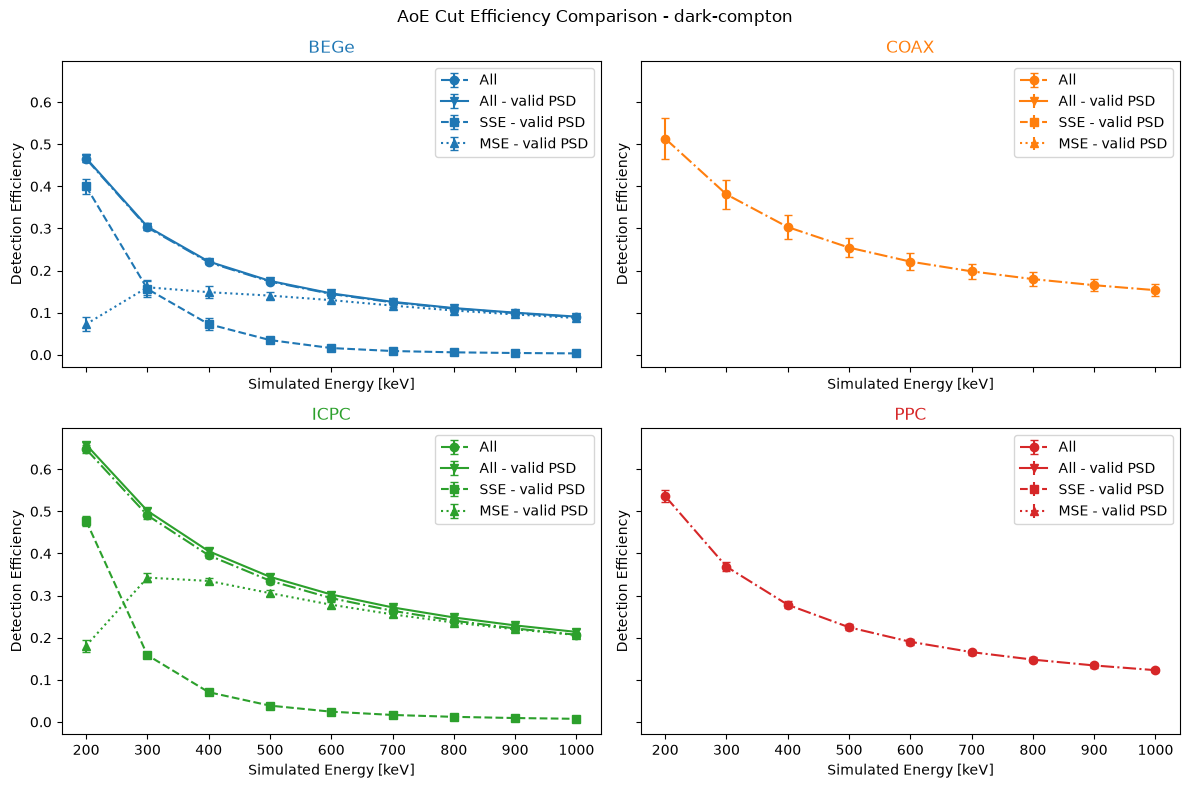

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)

for ax, det_type in zip(axes.flat, DET_TYPES):
    color = DET_TYPE_COLOR[det_type]
    for label, means, ls, marker in labels_dicts:
        enes, vals, uncs = [], [], []
        for ene in sorted(means.keys()):
            entry = means[ene].get(det_type)
            if entry is None:
                continue
            enes.append(ene)
            vals.append(entry["value"])
            uncs.append(entry["unc"])
        ax.errorbar(
            enes, vals, yerr=uncs,
            fmt=marker, ls=ls, color=color,
            label=label, capsize=3,
        )    
    ax.set_title(det_type, color=color)
    ax.set_xlabel("Simulated Energy [keV]")
    ax.set_ylabel("Detection Efficiency")
    ax.legend()
fig.suptitle(f"AoE Cut Efficiency Comparison - {interaction}")
fig.tight_layout()
plt.savefig(f"../plots/AoE/{interaction}_detection-efficiency.png", dpi = 400)
plt.show()

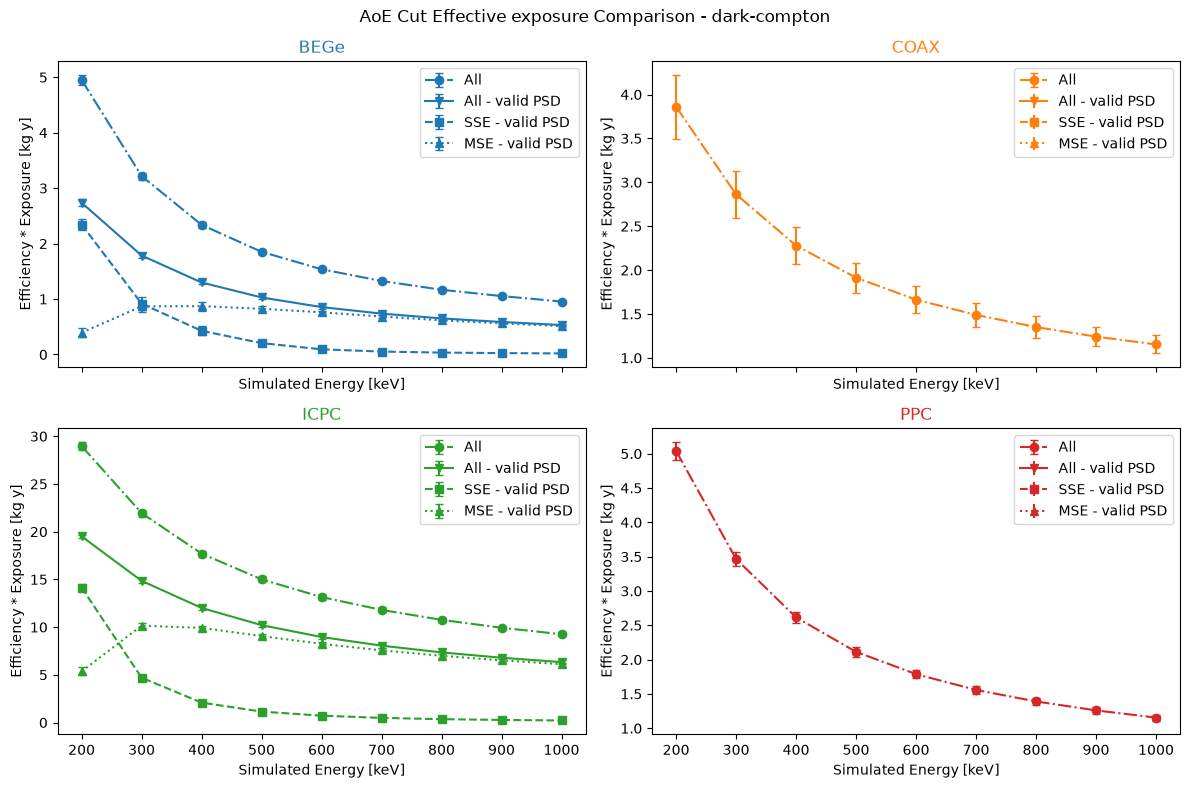

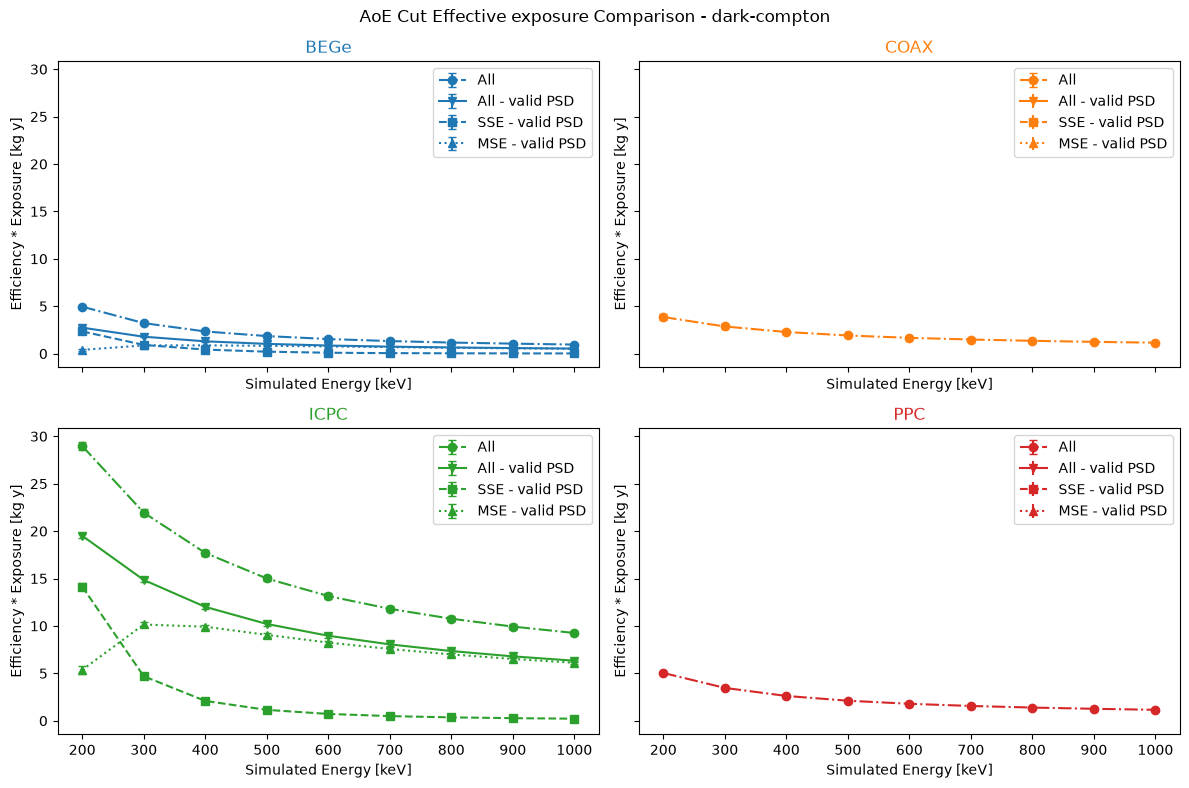

In [9]:
for share_y_title, sharey in zip(["", "_sharey"], [False, True]):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=sharey)

    for ax, det_type in zip(axes.flat, DET_TYPES):
        color = DET_TYPE_COLOR[det_type]
        for label, means, ls, marker in labels_dicts:
            enes, vals, uncs = [], [], []
            for ene in sorted(means.keys()):
                entry = means[ene].get(det_type)
                if entry is None:
                    continue
                enes.append(ene)
                vals.append(entry["value"]*entry["exposure"])
                uncs.append(entry["unc"]*entry["exposure"])
            ax.errorbar(
                enes, vals, yerr=uncs,
                fmt=marker, ls=ls, color=color,
                label=label, capsize=3,
            )    
        ax.set_title(det_type, color=color)
        ax.set_xlabel("Simulated Energy [keV]")
        ax.set_ylabel("Efficiency * Exposure [kg y]")
        ax.legend()
    fig.suptitle(f"AoE Cut Effective exposure Comparison - {interaction}")
    fig.tight_layout()
    plt.savefig(f"../plots/AoE/{interaction}_effective-exposure{share_y_title}.png", dpi = 400)
    plt.show()

In [15]:
B = []
C = []
I = []
P = []

Bs = []
Cs = []
Is = []
Ps = []

for ene in ratio_dict_means.keys():

    B.append(ratio_dict_means[ene]['BEGe']['value'])
    I.append(ratio_dict_means[ene]['ICPC']['value'])
    C.append(ratio_dict_means[ene]['COAX']['value'])
    P.append(ratio_dict_means[ene]['PPC']['value'])
    
    Bs.append(ratio_dict_means[ene]['BEGe']['unc'])
    Is.append(ratio_dict_means[ene]['ICPC']['unc'])
    Cs.append(ratio_dict_means[ene]['COAX']['unc'])
    Ps.append(ratio_dict_means[ene]['PPC']['unc'])

B = np.array(B)
C = np.array(C)
I = np.array(I)
P = np.array(P)

Bs = np.array(Bs)
Cs = np.array(Cs)
Is = np.array(Is)
Ps = np.array(Ps)


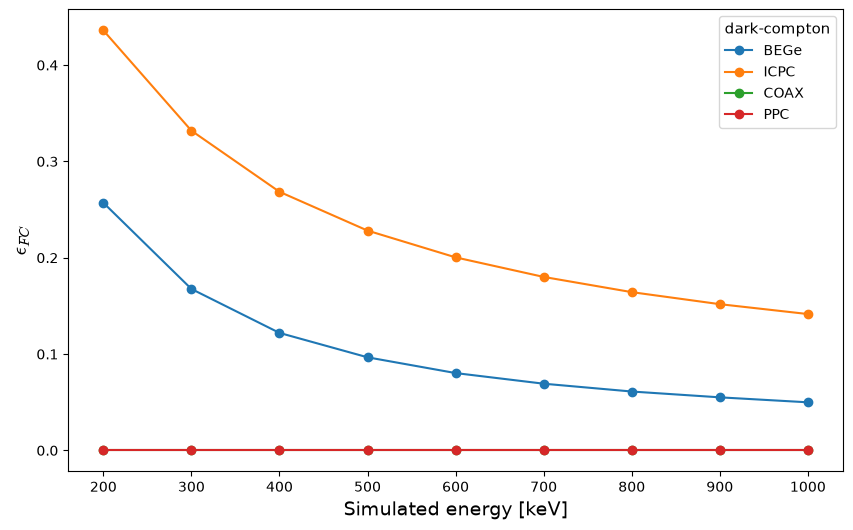

In [16]:
x = ratio_dict_means.keys()
plt.rcParams["mathtext.fontset"] = "cm"
plt.figure(figsize=(10,6))

plt.plot(x, B, marker = 'o', label = 'BEGe')
plt.plot(x, I, marker = 'o', label = 'ICPC')
plt.plot(x, C, marker = 'o', label = 'COAX')
plt.plot(x, P, marker = 'o', label = 'PPC')

plt.xlabel('Simulated energy [keV]', fontsize = 14)
plt.ylabel(r"$\epsilon_{FC}$", fontsize = 15)
plt.legend(title=f'{interaction}', 
           title_fontsize=11, loc = "upper right", 
           alignment="left")
# plt.savefig('./plots/dark-compton/FC-eff_det-type_dark-compton.png', dpi = 500)
plt.show()

In [ ]:
x = ratio_dict_means.keys()
plt.rcParams["mathtext.fontset"] = "cm"
plt.figure(figsize=(10,6))

plt.errorbar(x, B, yerr = Bs, marker = '.', label = 'BEGe')
plt.errorbar(x, I, yerr = Is, marker = '.', label = 'ICPC')
plt.errorbar(x, C, yerr = Cs, marker = '.', label = 'COAX')
plt.errorbar(x, P, yerr = Ps, marker = '.', label = 'PPC')

plt.xlabel('Simulated energy [keV]', fontsize = 14)
plt.ylabel(r"$\epsilon_{FC}$", fontsize = 15)
plt.legend(title=f'{interaction}', 
           title_fontsize=11, loc = "upper right", 
           alignment="left")
plt.tight_layout()
# plt.savefig(f'./plots/dark-compton/FC-eff_det-type_{interaction}_errorbar.png', dpi = 500)
plt.show()

### tests with uncertainties

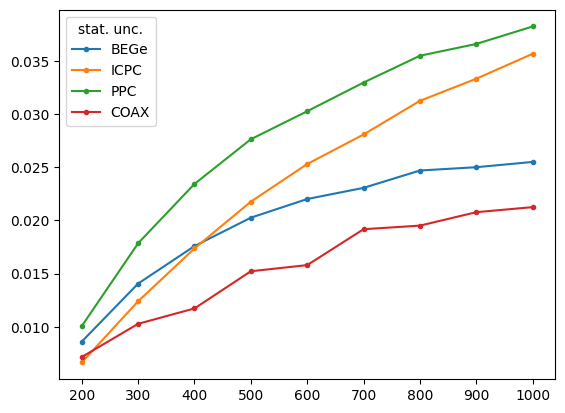

In [24]:
plt.errorbar(x, Bs/B, marker = '.', label = 'BEGe')
plt.errorbar(x, Is/B, marker = '.', label = 'ICPC')
plt.errorbar(x, Ps/B, marker = '.', label = 'PPC')
plt.errorbar(x, Cs/B, marker = '.', label = 'COAX')

plt.legend(title="stat. unc.")
plt.show()

In [ ]:
ges_sorted = chmap_ak.name

values_dict = {}

fig, ax = plt.subplots(figsize=(16, 7))  # larghezza generosa per spaziatura

for ene in tqdm(simulated_energies):
    
    keys, values = get_values_sorted(ratio_dict[ene], ges_sorted)
    tag = f'{ene}keV'
    ax.scatter(keys, values, marker = 'o', label=tag)


plt.xticks(ticks=range(len(keys)), labels=keys, rotation=90, ha='center')

ax.set_ylabel(r"$\epsilon_{FC}$", fontsize = 16)
ax.margins(x=0.02)  # riduce il padding laterale (default è 0.05)
# ax.set_ylim(0.75, 1)
plt.legend(ncol = 3, title=f'{interaction}', title_fontsize=13)
plt.tight_layout()

plt.savefig(f"./plots/{interaction}/FC-efficiency_{interaction}.png", dpi=500)
plt.show()


  0%|          | 0/9 [00:00<?, ?it/s]

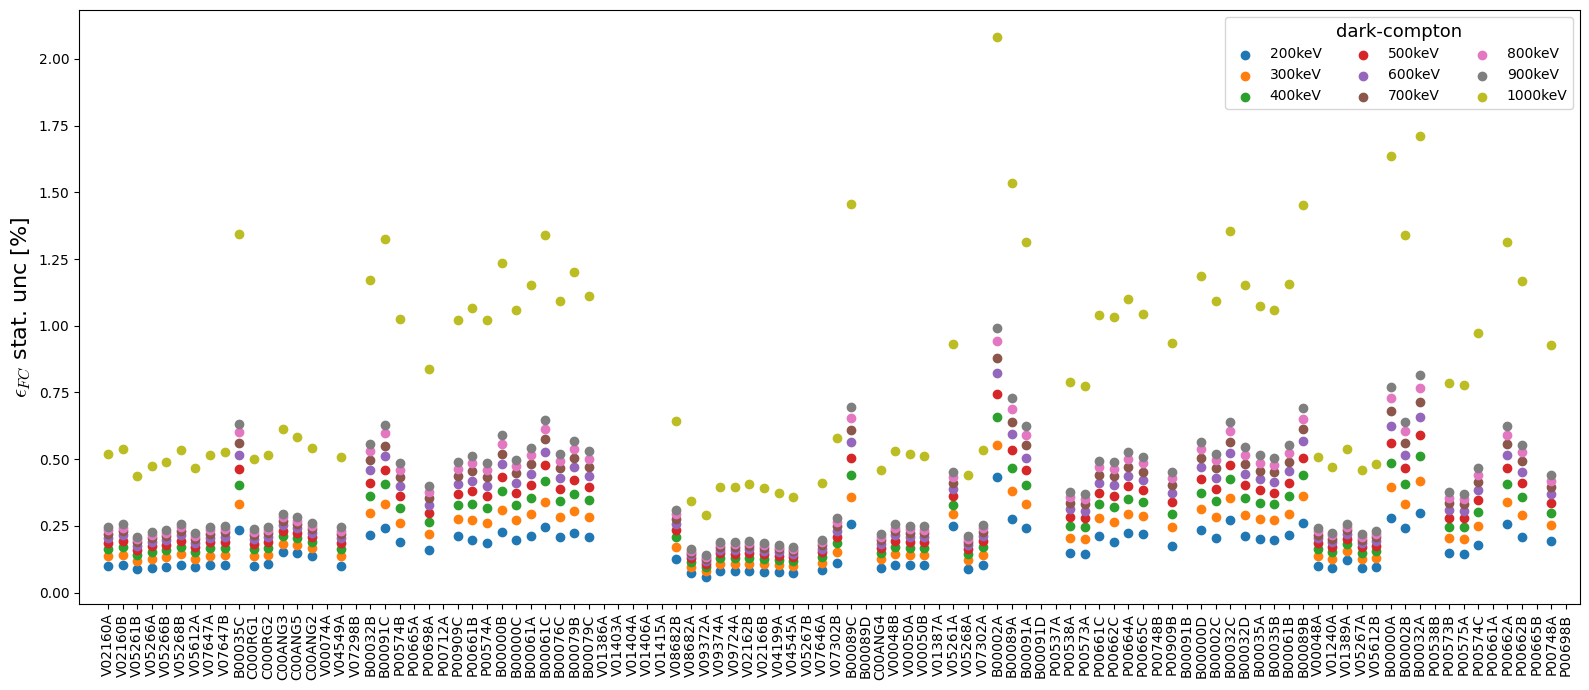

In [21]:
ges_sorted = chmap_ak.name

values_dict = {}

fig, ax = plt.subplots(figsize=(16, 7))  # larghezza generosa per spaziatura

for ene in tqdm(simulated_energies):
    
    keys, ratio = get_values_sorted(ratio_dict[ene], ges_sorted, key = 'ratio')
    keys, sigma = get_values_sorted(ratio_dict[ene], ges_sorted, key = 'ratio_sigma')
    tag = f'{ene}keV'
    ax.scatter(keys, np.array(sigma)/np.array(ratio)*100, marker = 'o', label=tag)


plt.xticks(ticks=range(len(keys)), labels=keys, rotation=90, ha='center')

plt.ylabel(r"$\epsilon_{FC}$ stat. unc [%]", fontsize = 16)
ax.margins(x=0.02)  # riduce il padding laterale (default è 0.05)
# ax.set_ylim(0.75, 1)
plt.legend(ncol = 3, title=f'{interaction}', title_fontsize=13)

plt.tight_layout()
plt.savefig(f"./plots/{interaction}/FC-stat-unc_{interaction}.png", dpi=500)
plt.show()

In [52]:
stat_unc_dict = {}

ratio_dict = Props.read_from(f"{dictionaries_dir}/dark-compton_ratio-dict.yaml")
ratio_dict_axio = Props.read_from(f"{dictionaries_dir}/axio-effect_ratio-dict.yaml")

stat_unc_dict['dark'] = {}
stat_unc_dict['axio'] = {}


for ene in tqdm(simulated_energies):
    keys, ratio = get_values_sorted(ratio_dict[ene], ges_sorted, key = 'ratio')
    keys, sigma = get_values_sorted(ratio_dict[ene], ges_sorted, key = 'ratio_sigma')
    stat_unc_dict['dark'][ene] = np.array(sigma)/np.array(ratio)*100
    
    keys, ratio = get_values_sorted(ratio_dict_axio[ene], ges_sorted, key = 'ratio')
    keys, sigma = get_values_sorted(ratio_dict_axio[ene], ges_sorted, key = 'ratio_sigma')
    stat_unc_dict['axio'][ene] = np.array(sigma)/np.array(ratio)*100


  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

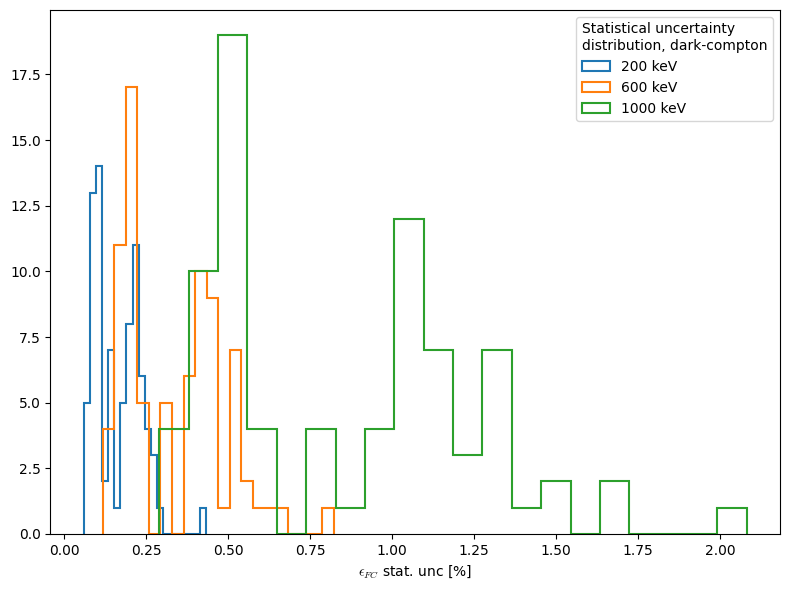

In [27]:
lw = 1.5
plt.figure(figsize=(8,6))
for ene in tqdm(np.array(simulated_energies)[[0, 4, -1]]):

    plt.hist(
        stat_unc_dict[ene], 
        bins = 20, 
        label=f"{ene} keV", 
        histtype="step", 
        linewidth=lw
    )
plt.legend(
    title=f"Statistical uncertainty \ndistribution, {interaction}",
    alignment="left"
)

plt.xlabel(r"$\epsilon_{FC}$ stat. unc [%]")
plt.tight_layout()
plt.show()

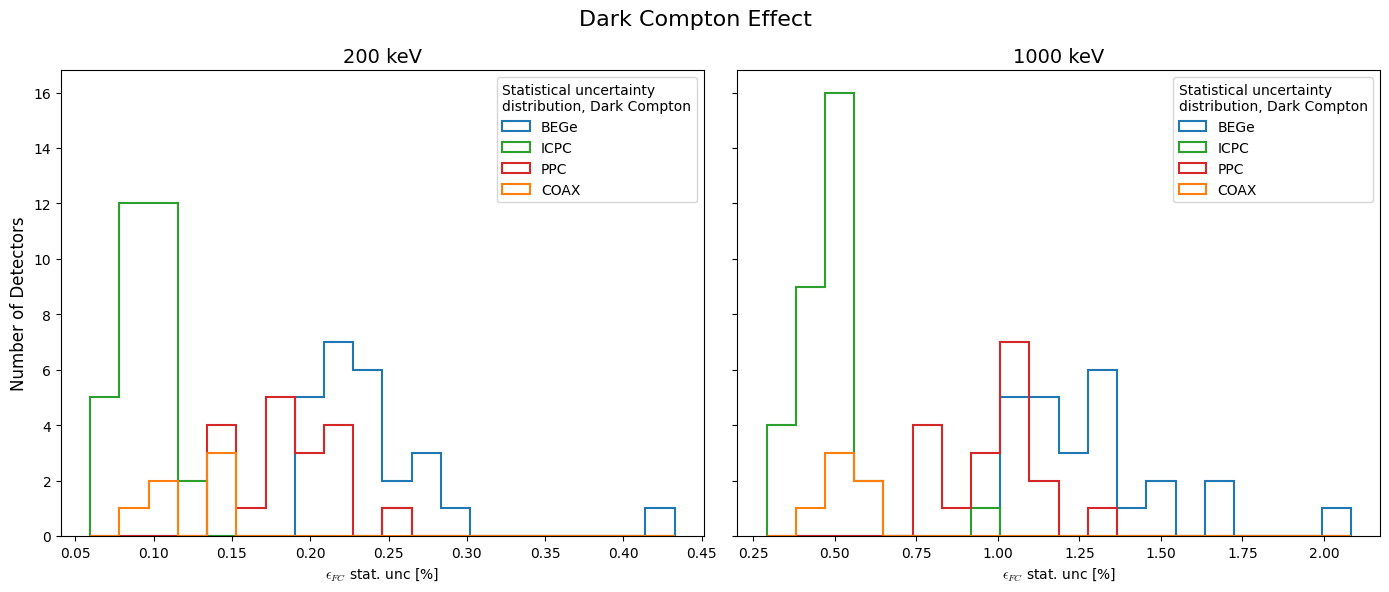

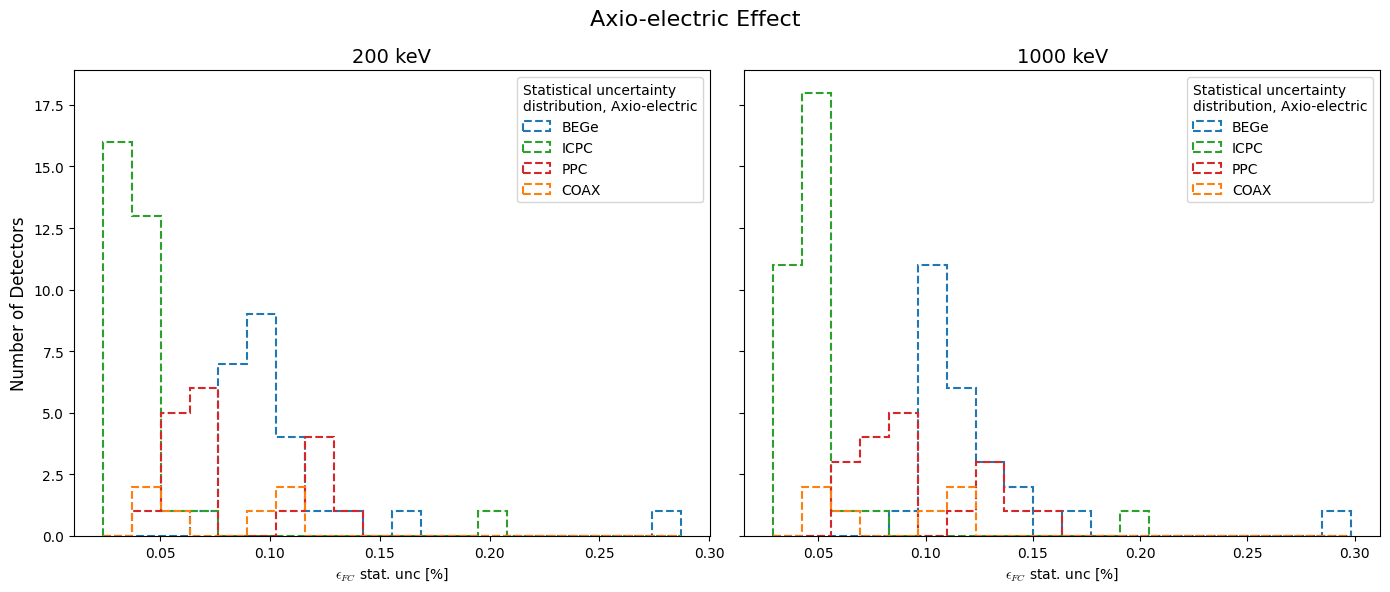

In [62]:
det_types = np.array([_DET_TYPE_MAP[ge[0].upper()] for ge in ges_sorted])
target_energies = [200, 1000]

fig1, axes1 = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, ene in zip(axes1, target_energies):
    # Calcola il binning specifico per il Dark Compton a questa energia
    dark_finite = stat_unc_dict['dark'][ene][np.isfinite(stat_unc_dict['dark'][ene])]
    bin_edges = np.linspace(dark_finite.min(), dark_finite.max(), 21)
    for det_type in ["BEGe", "ICPC", "PPC", "COAX"]:
        vals_dark = stat_unc_dict['dark'][ene][det_types == det_type]
        vals_dark = vals_dark[np.isfinite(vals_dark)]
        
        ax.hist(
            vals_dark, 
            bins=bin_edges,
            label=det_type, 
            color=DET_TYPE_COLOR[det_type],
            histtype="step", 
            linewidth=lw
        )
        
    ax.legend(
        title="Statistical uncertainty \ndistribution, Dark Compton",
        alignment="left"
    )
    ax.set_title(f"{ene} keV", fontsize=14)
    ax.set_xlabel(r"$\epsilon_{FC}$ stat. unc [%]")
    # ax.grid(True, linestyle="--", alpha=0.5)
axes1[0].set_ylabel("Number of Detectors", fontsize=12)
fig1.suptitle("Dark Compton Effect", fontsize=16)
fig1.tight_layout()
fig1.savefig(f"./plots/dark-compton/stat-unc_hist_dark-compton.png", dpi=500)
fig1.show()
# ==========================================
# PLOT 2: Axio-electric Effect
# ==========================================
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, ene in zip(axes2, target_energies):
    # Calcola il binning specifico per l'Axio-electric a questa energia
    axio_finite = stat_unc_dict['axio'][ene][np.isfinite(stat_unc_dict['axio'][ene])]
    bin_edges = np.linspace(axio_finite.min(), axio_finite.max(), 21)
    for det_type in ["BEGe", "ICPC", "PPC", "COAX"]:
        vals_axio = stat_unc_dict['axio'][ene][det_types == det_type]
        vals_axio = vals_axio[np.isfinite(vals_axio)]
        
        ax.hist(
            vals_axio, 
            bins=bin_edges,
            label=det_type, 
            color=DET_TYPE_COLOR[det_type],
            histtype="step", 
            linewidth=lw,
            ls = "--"
        )
        
    ax.legend(
        title="Statistical uncertainty \ndistribution, Axio-electric",
        alignment="left"
    )
    ax.set_title(f"{ene} keV", fontsize=14)
    ax.set_xlabel(r"$\epsilon_{FC}$ stat. unc [%]")
    # ax.grid(True, linestyle="--", alpha=0.5)
axes2[0].set_ylabel("Number of Detectors", fontsize=12)
fig2.suptitle("Axio-electric Effect", fontsize=16)
fig2.tight_layout()
fig2.savefig(f"./plots/axio-electric/stat-unc_hist_axio-electric.png", dpi=500)
fig2.show()


## LAr Survival Fraction

In [29]:
outdir_name = "dark-compton3"

lf = pl.scan_parquet(
    f"{datasets_outdir}/{outdir_name}",
    hive_partitioning=True
)

  0%|          | 0/9 [00:00<?, ?it/s]

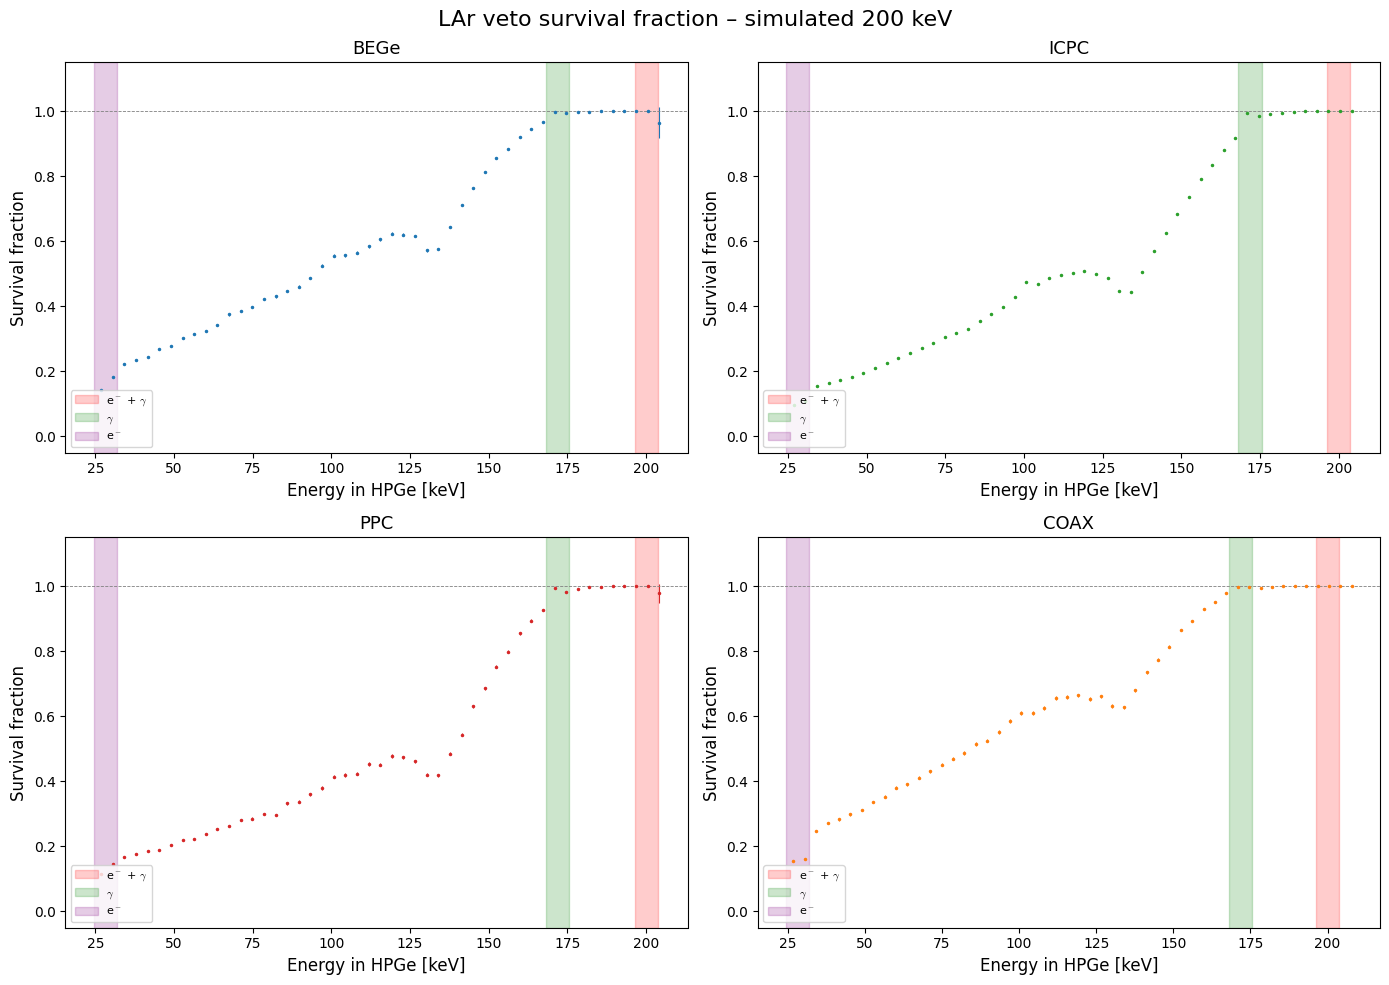

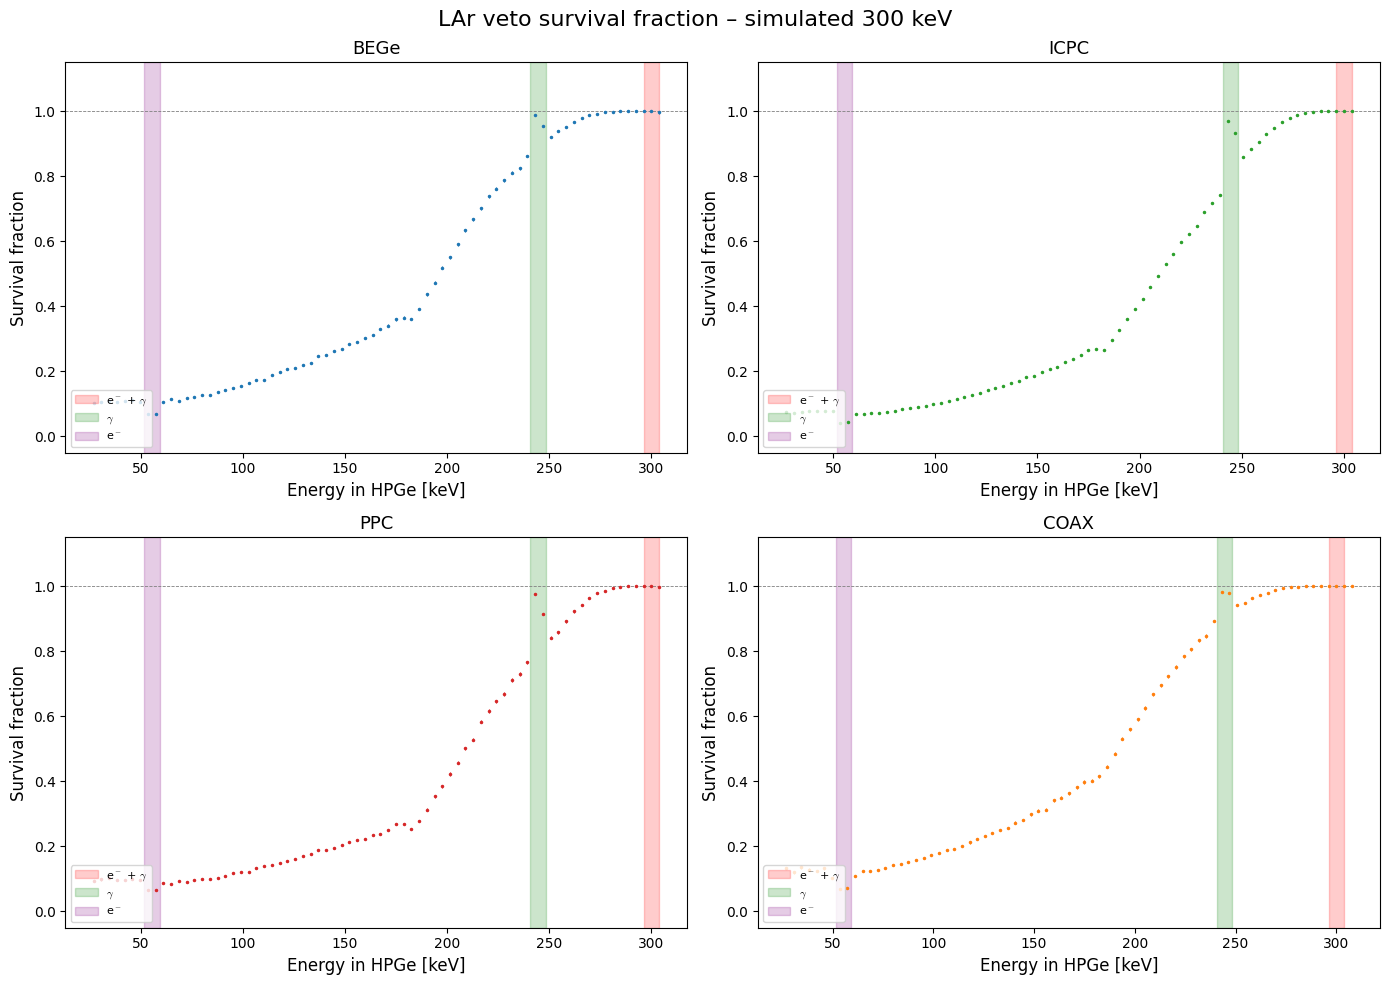

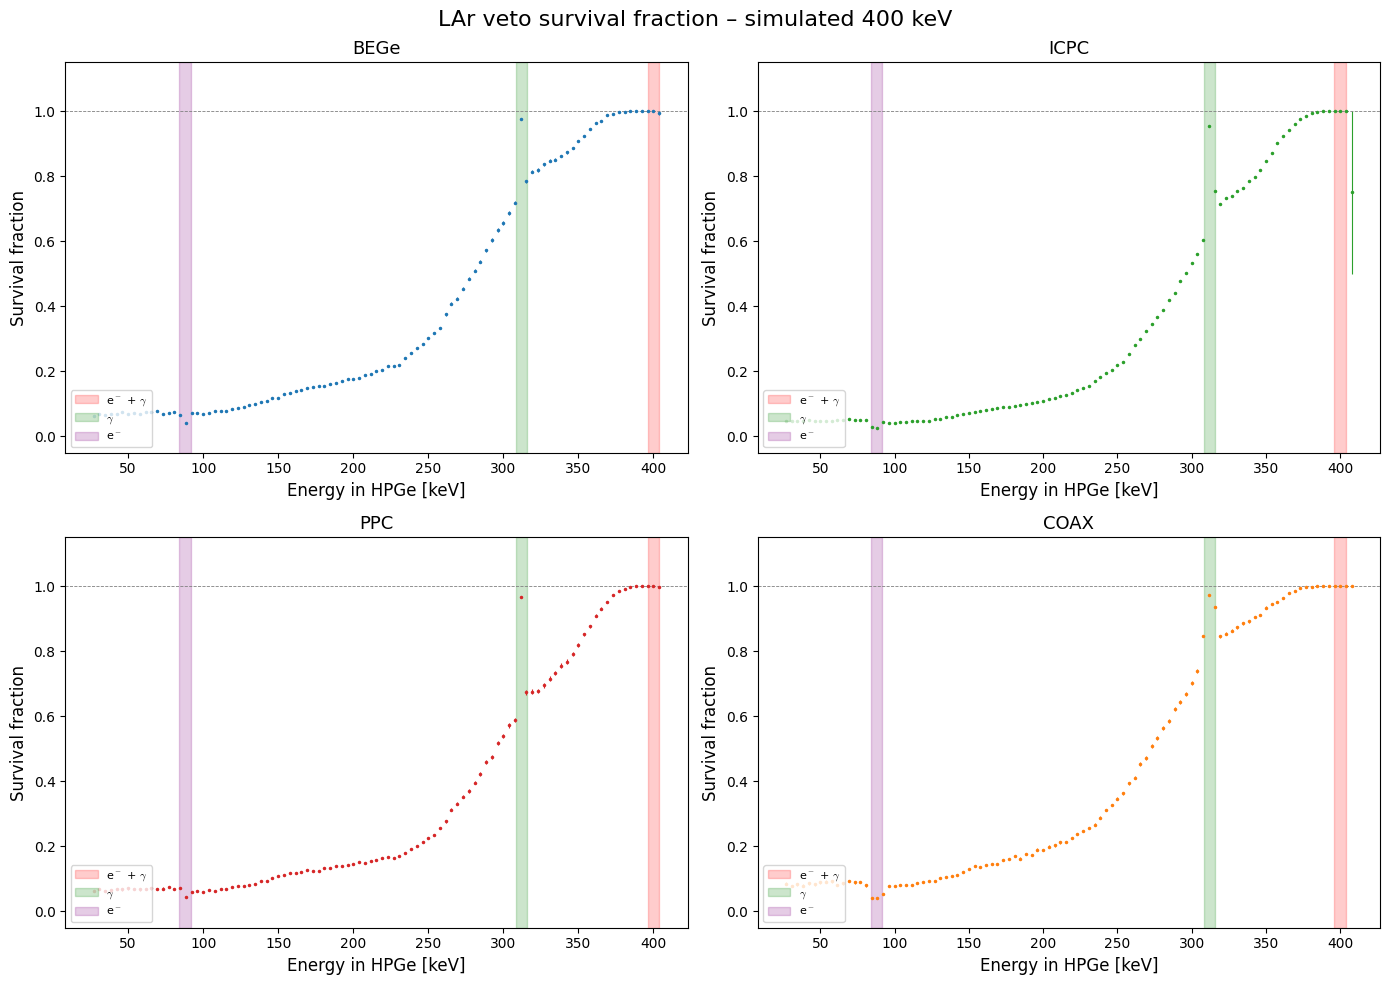

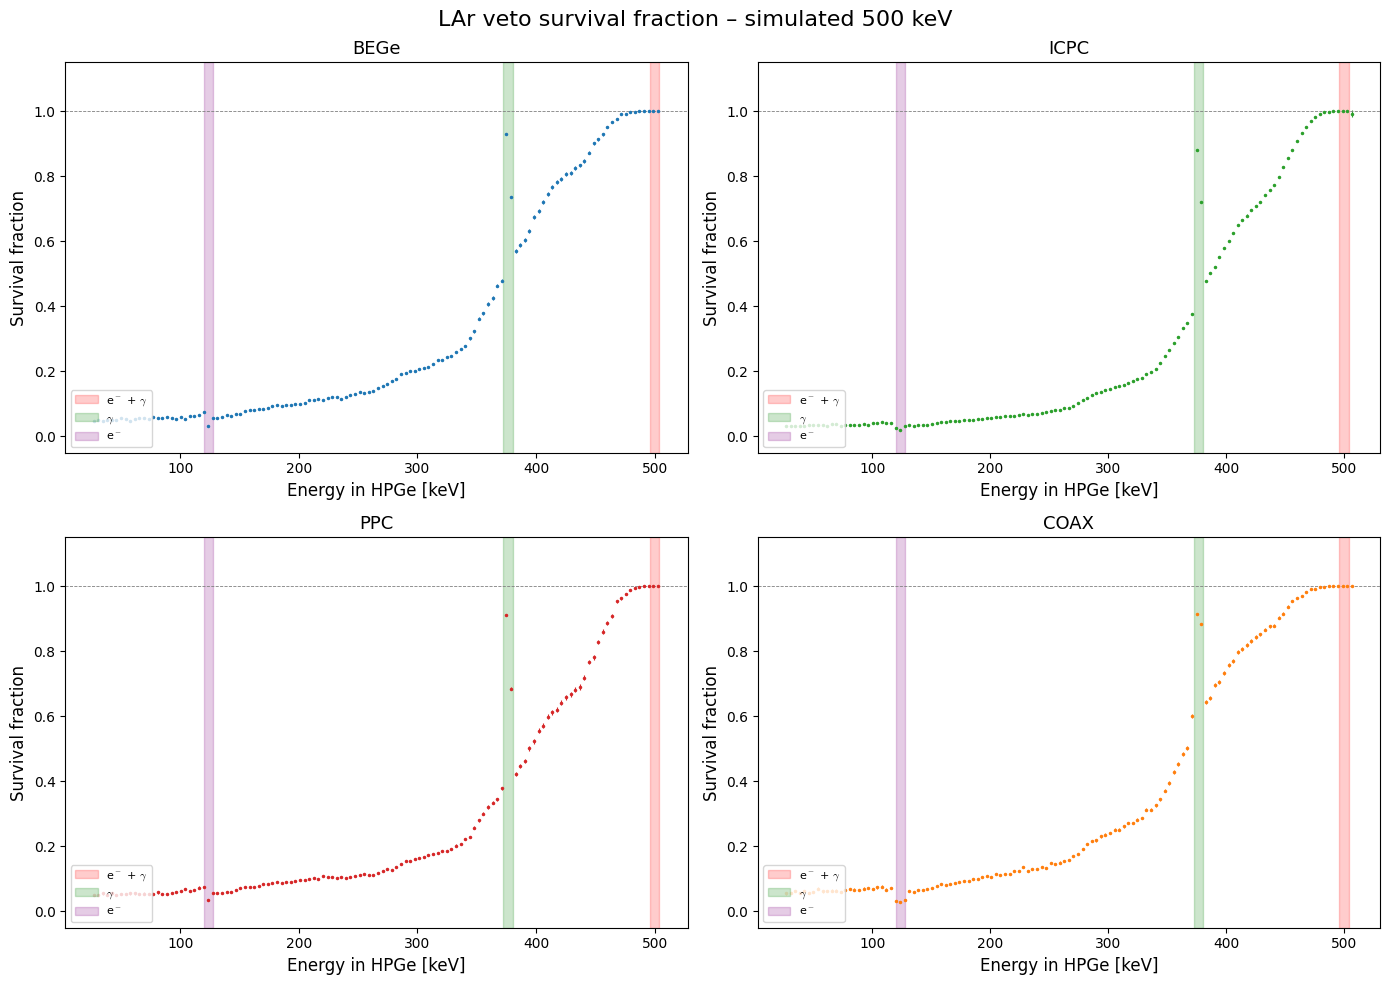

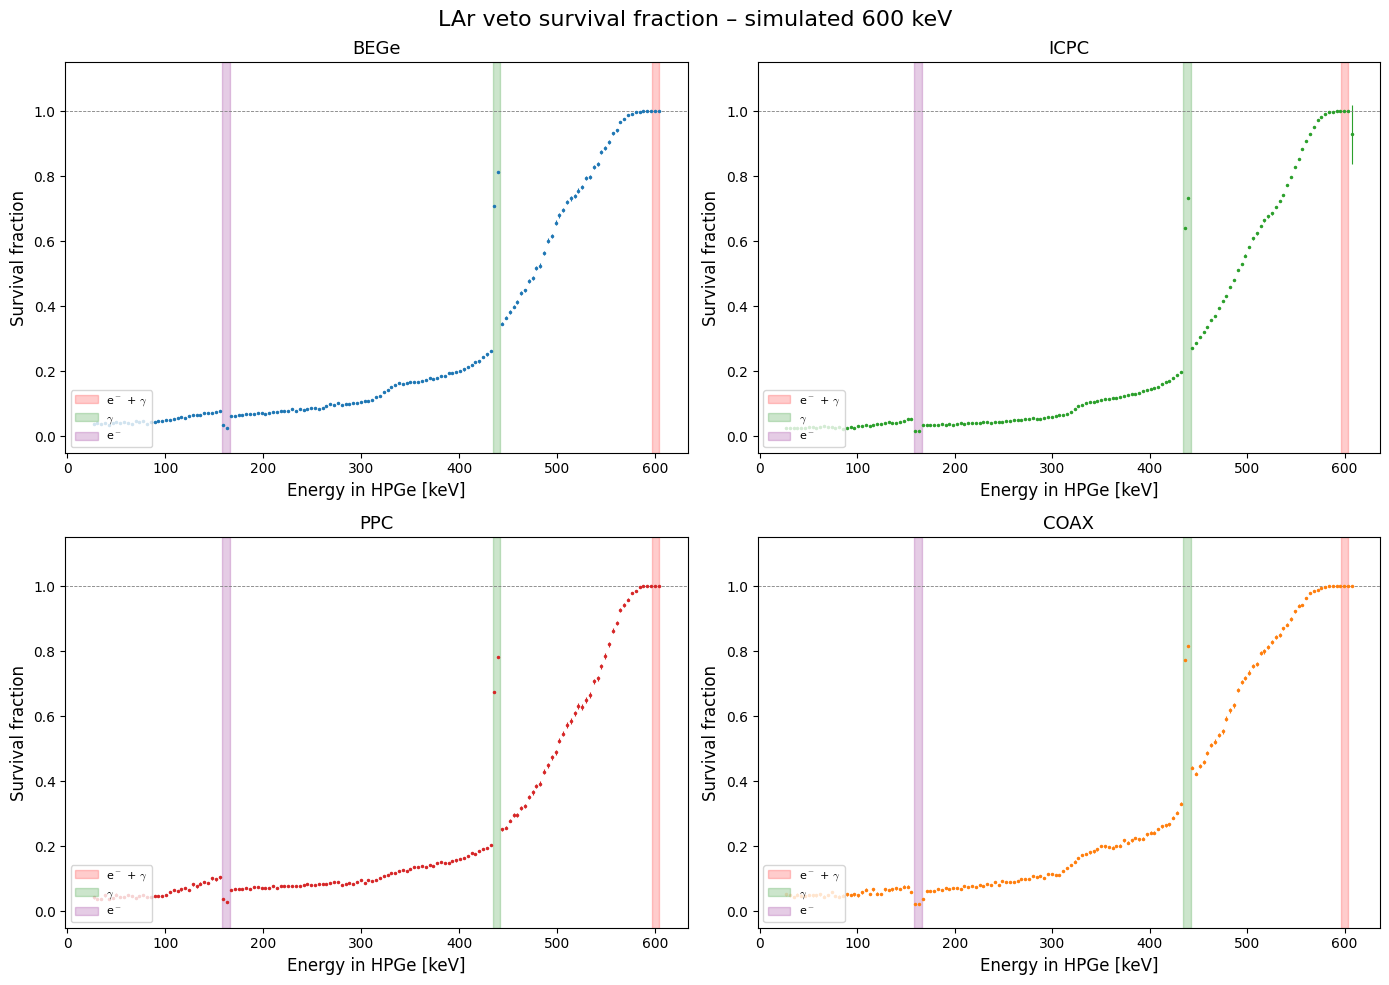

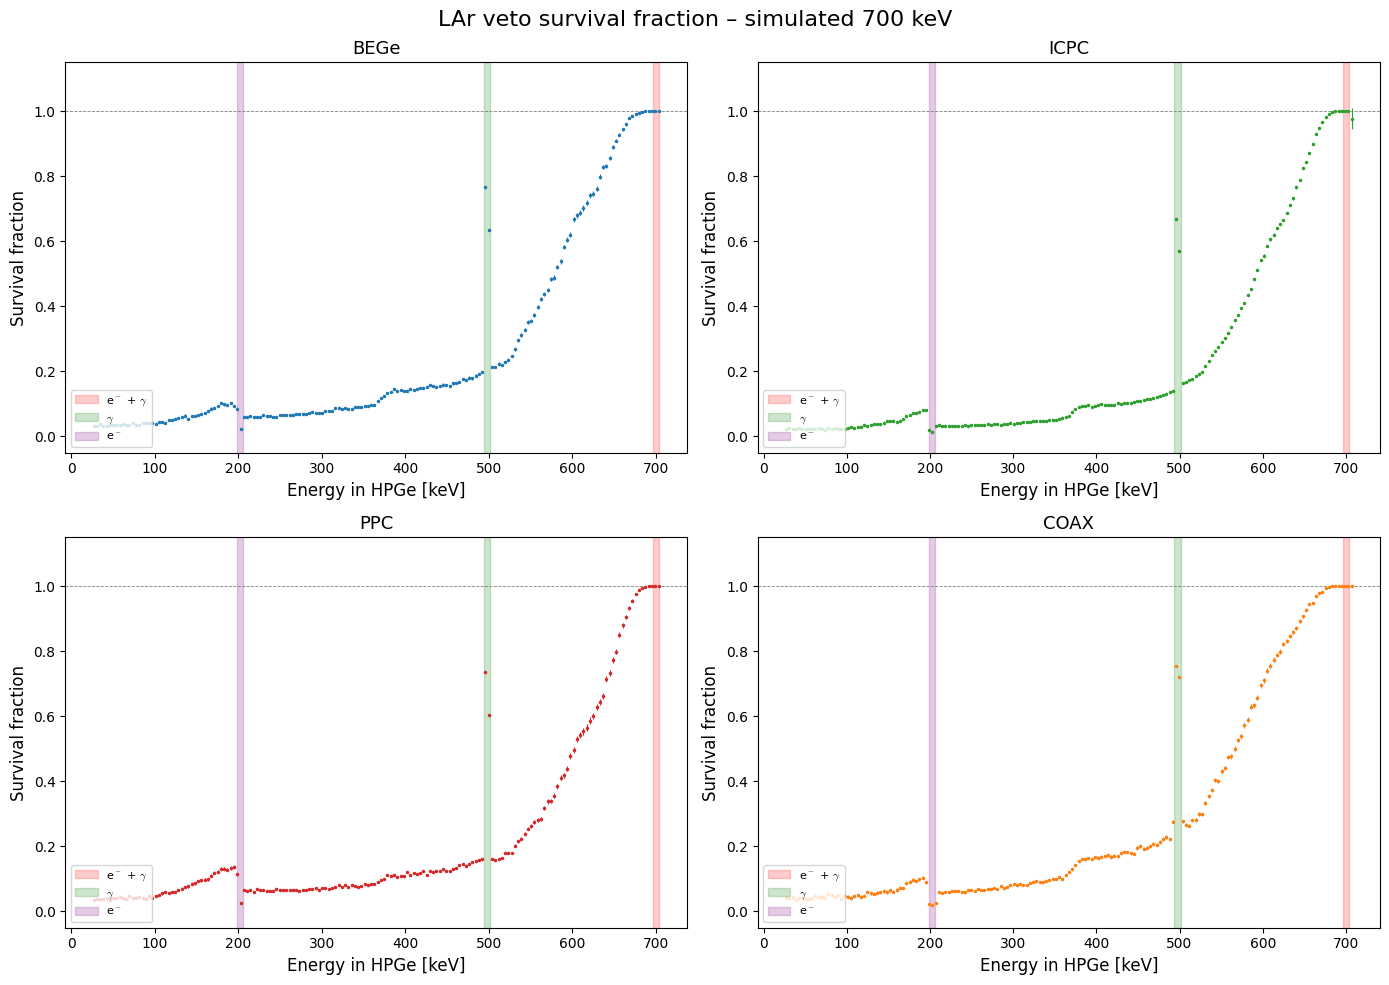

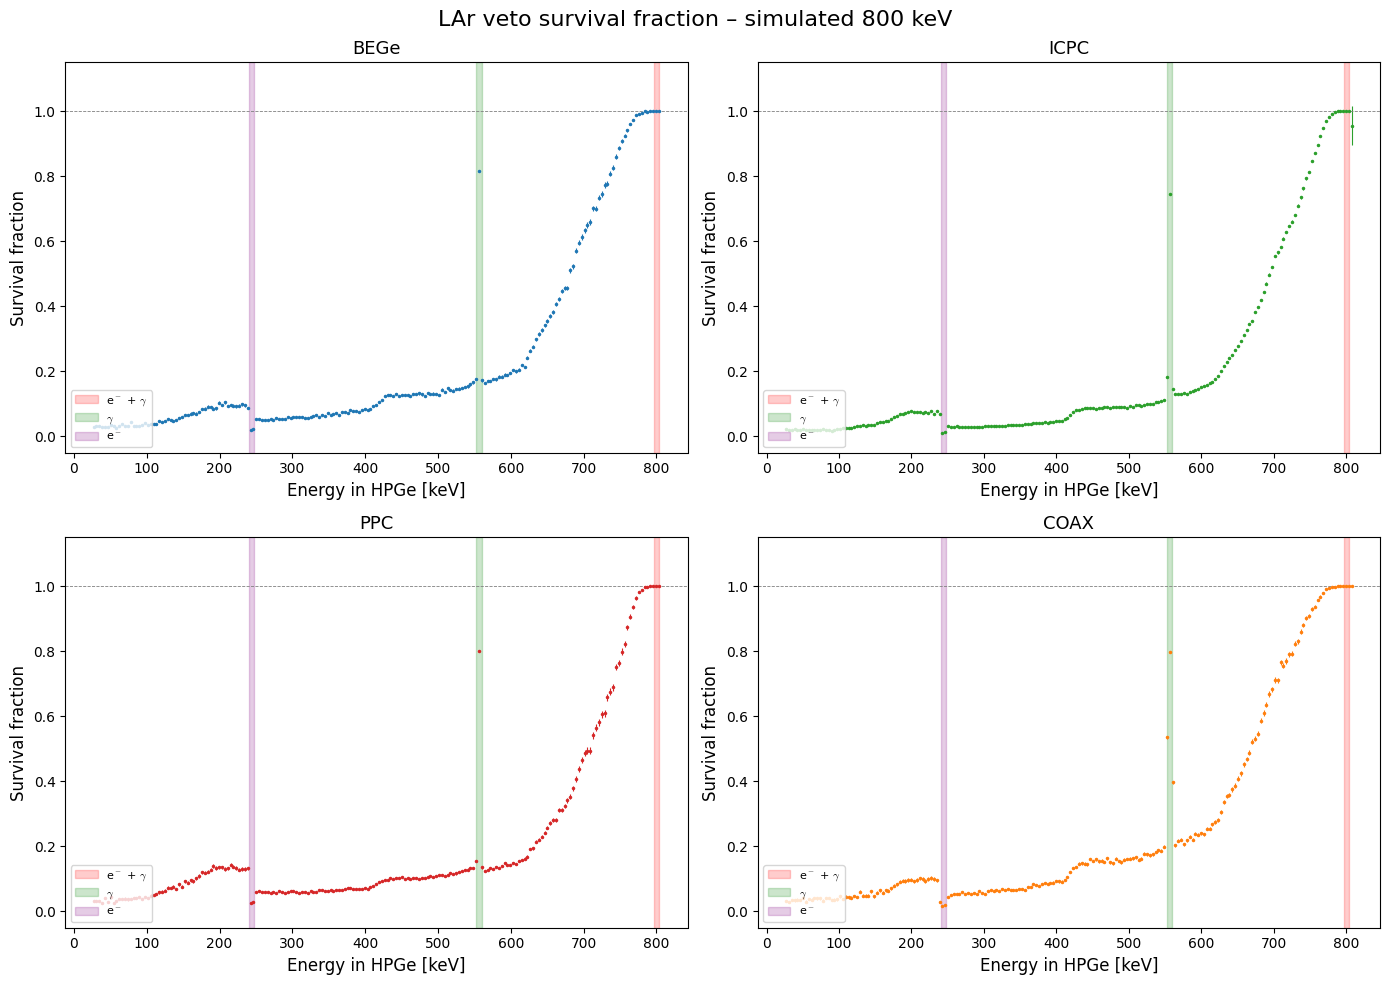

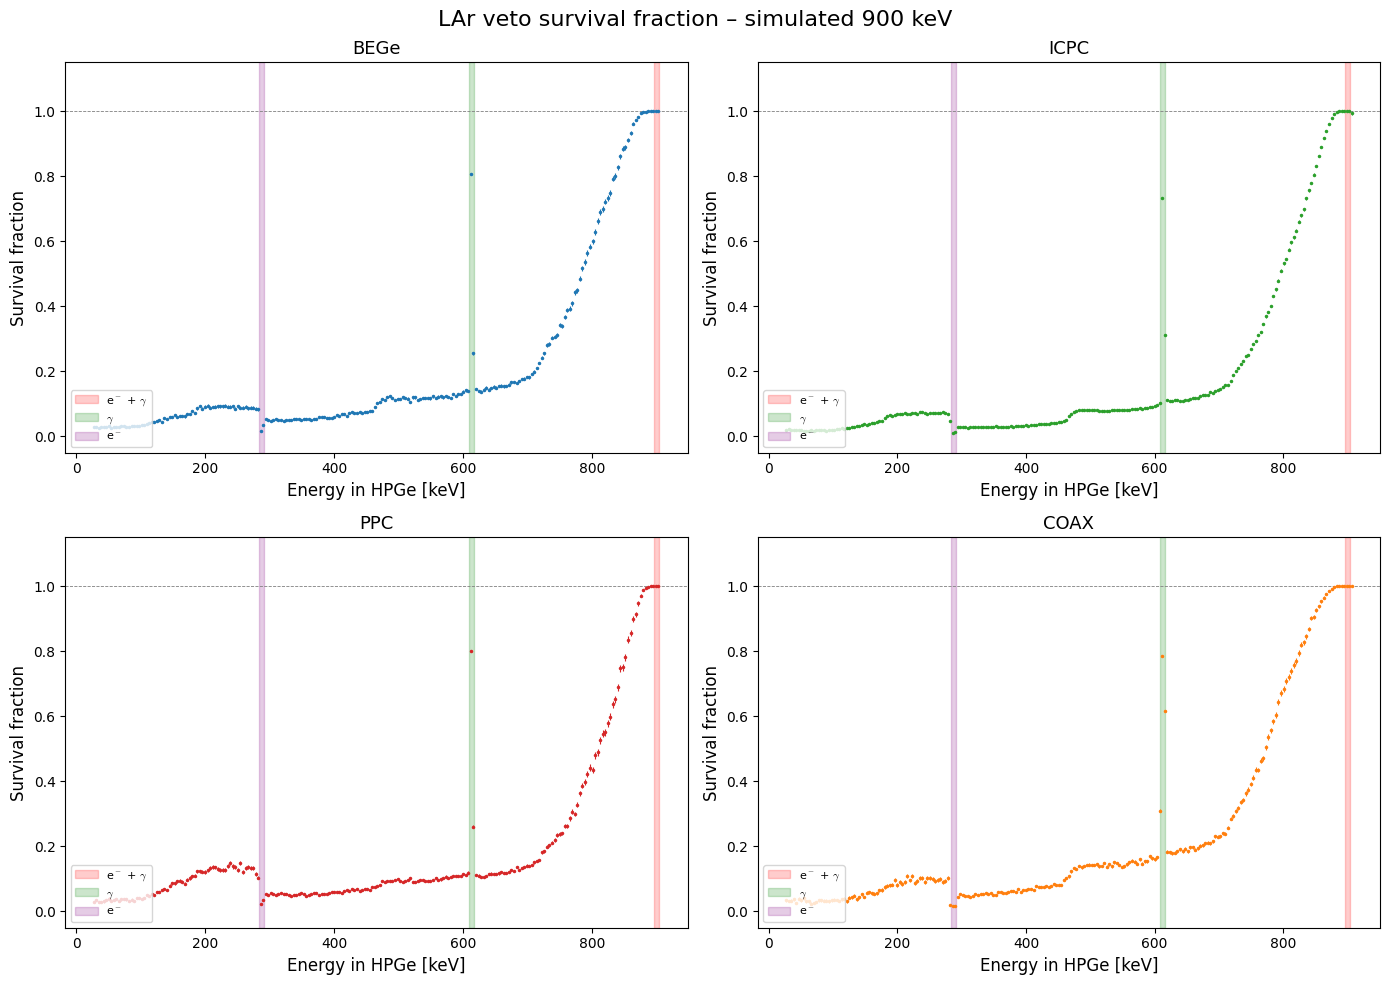

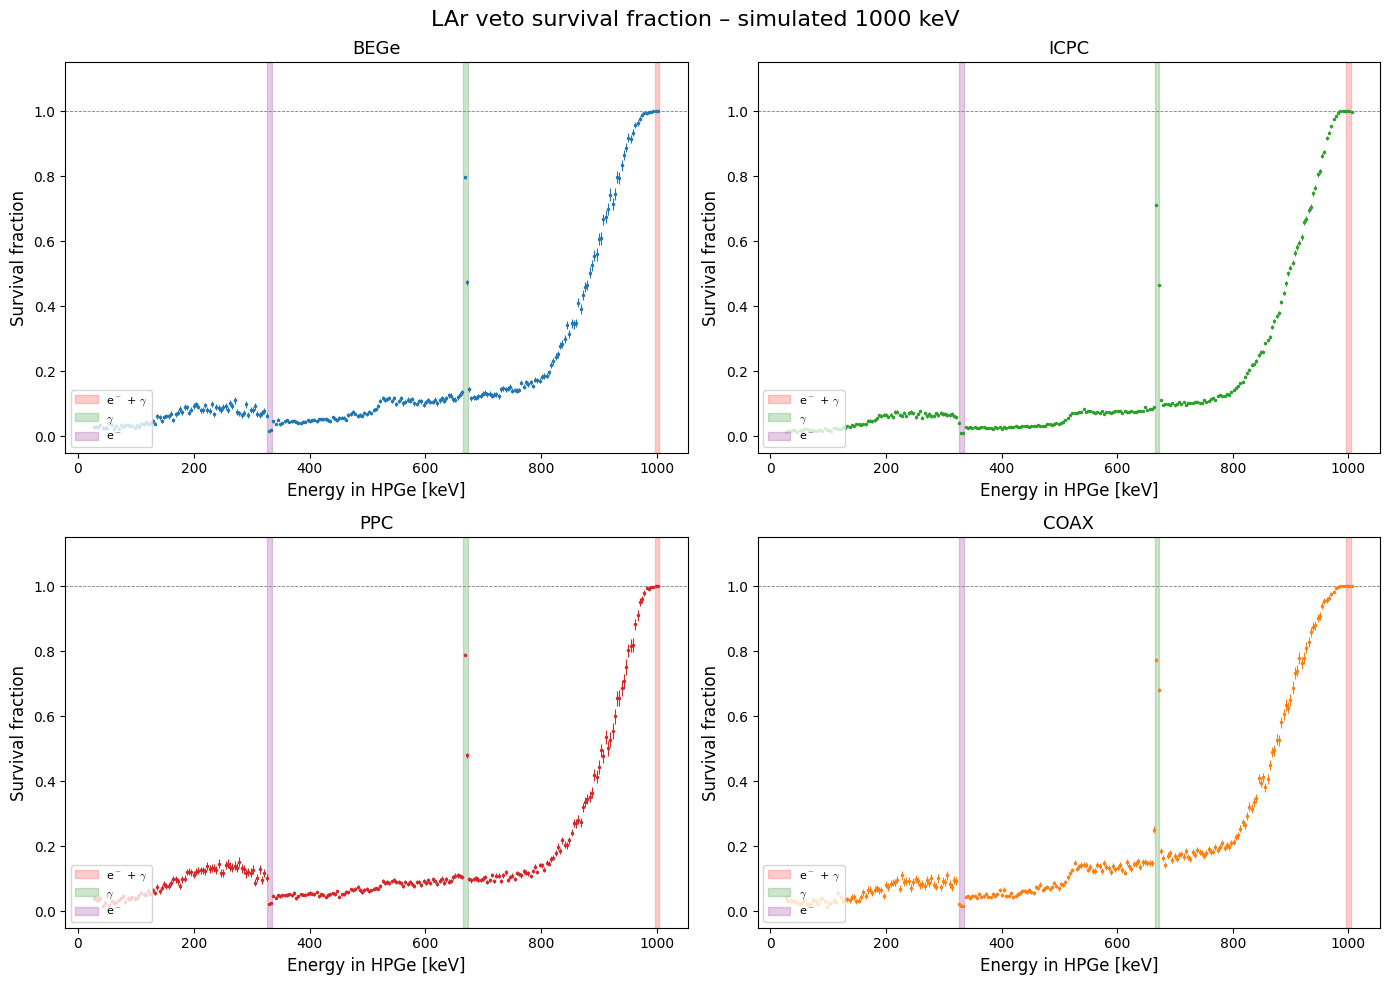

In [64]:
plot_lar_cut_spectra(
    lf=lf,
    simulated_energies=simulated_energies,
    chmap=chmap,
    bin_factor=4,
)


## A/E

In [17]:
ene = 200
rawid = 1104002 #V05261B

filter_expr = (
    (pl.col("is_good_channel"))
    & (pl.col("sim_e") == ene)
    & (pl.col("rawid") == rawid)
)

df_ene = (
    lf.filter(filter_expr)
    .collect()
)
len(df_ene), sum(df_ene['has_aoe'])

In [6]:
means_all = get_mean_fcc_det_type(ratio_dict, key="ratio", weight_key="expo",
                                   unc_key="ratio_sigma")
means_sse = get_mean_fcc_det_type(ratio_dict_SSE, key="ratio", weight_key="expo",
                                   unc_key="ratio_sigma")
means_mse = get_mean_fcc_det_type(ratio_dict_MSE, key="ratio", weight_key="expo",
                                   unc_key="ratio_sigma")


In [15]:
ratio_dict_SSE

{200: {'V02160A': {'n_events': 239143,
   'n_primaries': 506788,
   'ratio': 0.4718798158602495,
   'ratio_sigma': 0.0007012422350086743,
   'ratio_sigma_freq': 0.0007012436143161644,
   'ratio_syst_fwhm': 1.5785662277584267e-05,
   'expo': 1.1298439995436915},
  'V02160B': {'n_events': 243257,
   'n_primaries': 504196,
   'ratio': 0.482465187218488,
   'ratio_sigma': 0.0007037237623294848,
   'ratio_sigma_freq': 0.0007037251563439183,
   'ratio_syst_fwhm': 4.9583793636232e-06,
   'expo': 1.1098296201232034},
  'V05261B': {'n_events': 0,
   'n_primaries': 697432,
   'ratio': 7.169147430649253e-07,
   'ratio_sigma': 1.013869462420497e-06,
   'ratio_sigma_freq': 0.0,
   'ratio_syst_fwhm': 0.0,
   'expo': 1.5449809662331735},
  'V05266A': {'n_events': 0,
   'n_primaries': 605819,
   'ratio': 8.253276550790664e-07,
   'ratio_sigma': 1.1671881182451524e-06,
   'ratio_sigma_freq': 0.0,
   'ratio_syst_fwhm': 0.0,
   'expo': 1.3383809206023272},
  'V05266B': {'n_events': 0,
   'n_primaries': 5

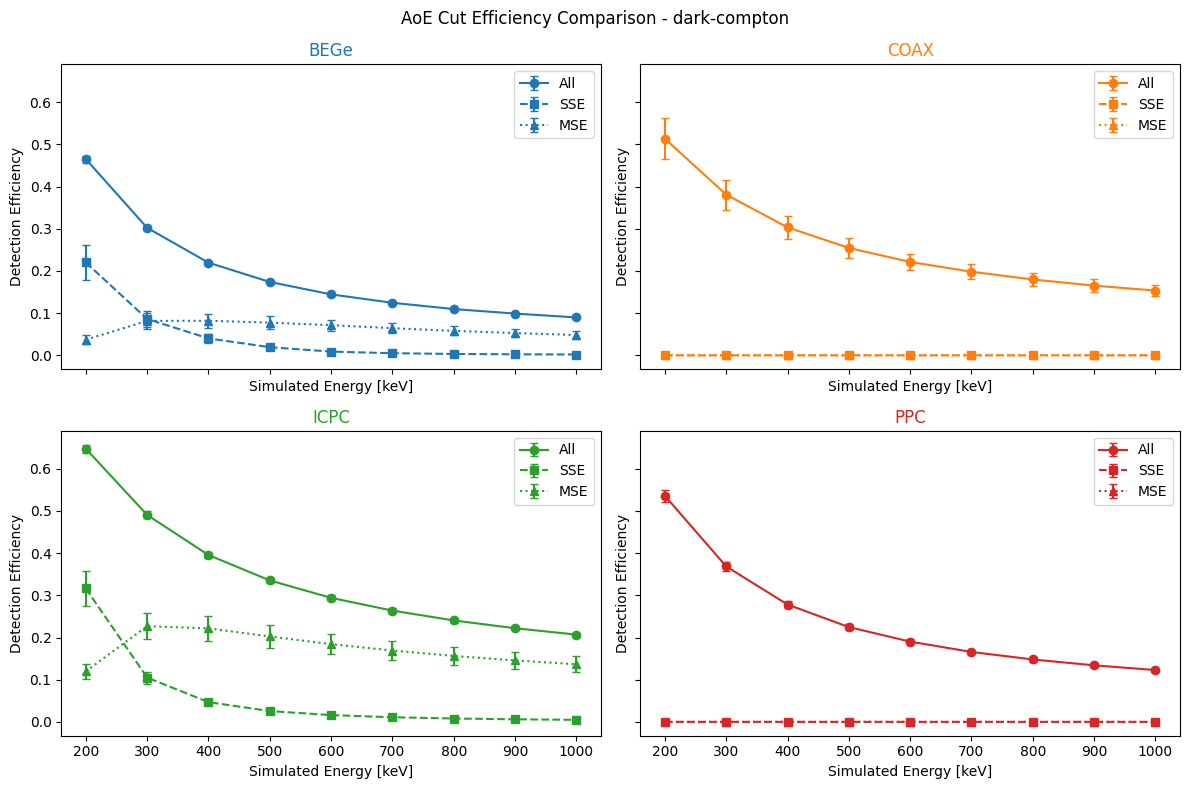

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)

labels_dicts = [
    ("All", means_all, "-",  "o"),
    ("SSE", means_sse, "--", "s"),
    ("MSE", means_mse, ":",  "^"),
]

for ax, det_type in zip(axes.flat, DET_TYPES):
    color = DET_TYPE_COLOR[det_type]
    for label, means, ls, marker in labels_dicts:
        enes, vals, uncs = [], [], []
        for ene in sorted(means.keys()):
            entry = means[ene].get(det_type)
            if entry is None:
                continue
            enes.append(ene)
            vals.append(entry["value"])
            uncs.append(entry["unc"])
        ax.errorbar(
            enes, vals, yerr=uncs,
            fmt=marker, ls=ls, color=color,
            label=label, capsize=3,
        )    
    ax.set_title(det_type, color=color)
    ax.set_xlabel("Simulated Energy [keV]")
    ax.set_ylabel("Detection Efficiency")
    ax.legend()
fig.suptitle(f"AoE Cut Efficiency Comparison - {interaction}")
fig.tight_layout()
plt.show()

## filter zero efficiency detectors

## Test

In [ ]:
import lgdo.lh5 as lh5

In [43]:
total_dict = {}

for ene in tqdm(np.array(simulated_energies)[[0, 2, -1]]):
    det_ene = {}

    job_string = f"fromfile_dark_compton_{ene}keV_hpge_bulk"
    stp_files = glob.glob(f"{scratch_folder}/generated/tier/stp/{job_string}/l200cfg01-{job_string}-job_*-tier_stp.lh5")

        
    for ge, eres_info in tqdm(eres_dict[ene].items()):
        fwhm = float(eres_info["fwhm"])
        fwhm_unc = float(eres_info.get("unc", 0.0))
    
        low = ene - 2.0 * fwhm
        high = ene + 2.0 * fwhm
    
        rawid = chmap[ge].daq.rawid
        stp_ge = lh5.read_as(f"/stp/{ge}", stp_files, library="ak")
        det_ene[ge] = {}
        df_filtered = (
                lf.filter(
                    (pl.col("rawid") == rawid)
                    & (pl.col("is_good_channel"))
                    & (pl.col("sim_e") == ene)
                )
                .select([
                    "energy"
                ])
                .collect()
            )
    
    
        # det_ene[ge]["energy"] = energies[channels == rawid]
        # tmp = energies[channels == rawid]
        n_events = df_filtered.filter(pl.col("energy").is_between(low, high)).height
        n_primaries = len(
            stp_ge.evtid
        )
        
        if n_primaries > 0:
            ratio = n_events / n_primaries
        else:
            ratio = np.nan
    
        det_ene[ge] = {
            "n_events": n_events,
            "n_primaries": n_primaries,
            "ratio": ratio,
        }
    
    total_dict[ene] = det_ene



  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/81 [00:00<?, ?it/s]

  0%|          | 0/81 [00:00<?, ?it/s]

  0%|          | 0/81 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

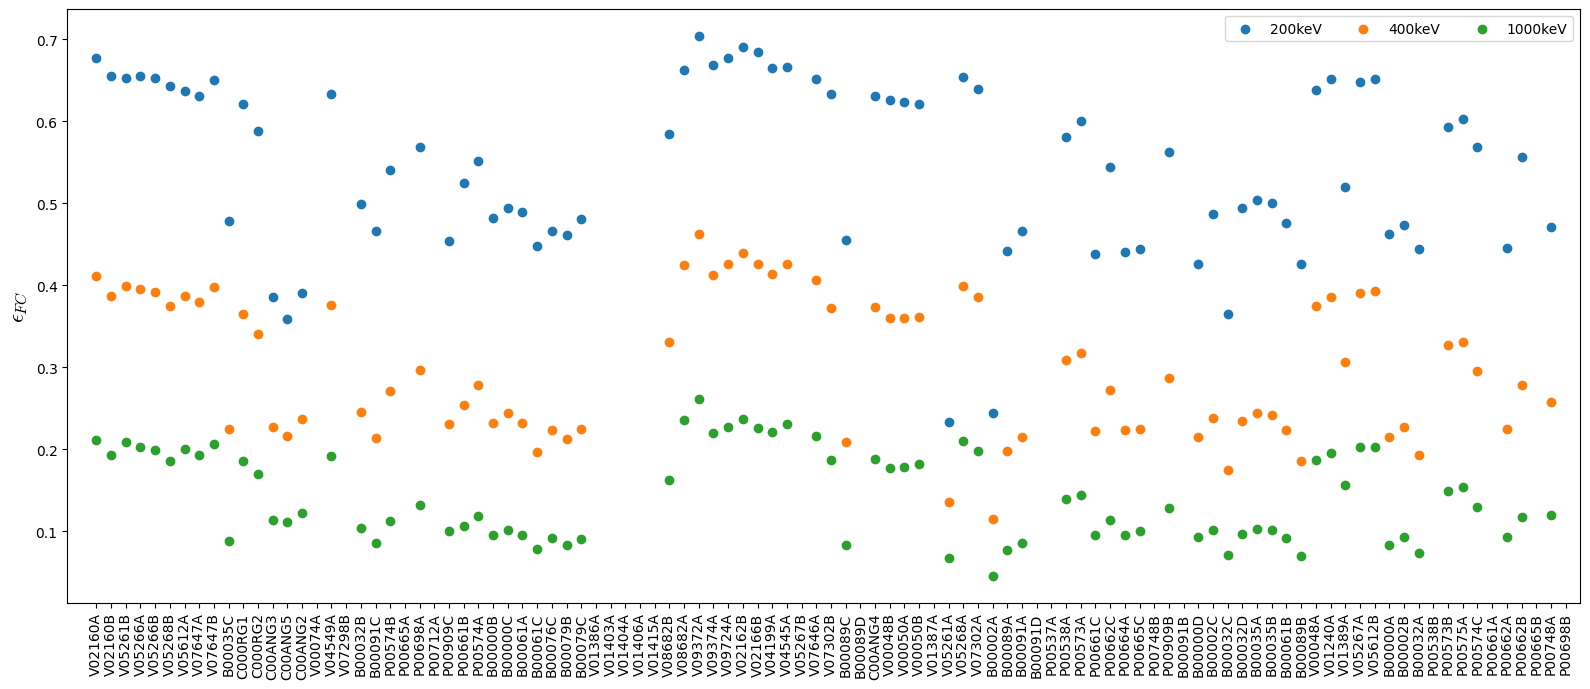

In [44]:
ges_sorted = chmap_ak.name

values_dict = {}

fig, ax = plt.subplots(figsize=(16, 7))  # larghezza generosa per spaziatura

for ene in tqdm(np.array(simulated_energies)[[0, 2, -1]]):
    
    keys, values = get_values_sorted(total_dict[ene], ges_sorted)
    tag = f'{ene}keV'
    ax.scatter(keys, values, marker = 'o', label=tag)


plt.xticks(ticks=range(len(keys)), labels=keys, rotation=90, ha='center')

ax.set_ylabel(r"$\epsilon_{FC}$", fontsize = 16)
ax.margins(x=0.02)  # riduce il padding laterale (default è 0.05)
# ax.set_ylim(0.75, 1)
plt.legend(ncol = 3)
# Padding sotto per non tagliare le etichette
plt.tight_layout()
# plt.savefig(f"./plots/{interaction}/FC-efficiency_{interaction}.png", dpi=500)
plt.show()
